# Análisis de Resultados

In [310]:
#%load_ext autoreload
#%autoreload 2

In [311]:
!pip install optuna --quiet
!pip install optuna-integration[sklearn]

In [312]:
# Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
#from xgboost import DMatrix
#from xgboost import train as xgbtrain
#from xgboost import plot_importance as xgb_plot_importance
import shap
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold

# Train model
# from ml_pipeline import *

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import statsmodels.api as sm
from scipy import stats
from statsmodels.iolib.summary2 import summary_col

# Utils
import warnings
import os
import json
import joblib

pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore", category=FutureWarning)

In [313]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
workin_dir = '/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura'
os.chdir(workin_dir)
import sys
# Add the directory containing the .py file to the Python path
sys.path.append(workin_dir) # Replace with the actual path if different

# Now you can import functions from your .py file
#from ml_pipeline import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [314]:
# Load list of columns
with open('Data/projectsColumns.txt', 'r') as f:
    projectsColumns = f.read().splitlines()
with open('Data/ownerColumns.txt', 'r') as f:
    ownerColumns = f.read().splitlines()
with open('Data/contractorColumns.txt', 'r') as f:
    contractorColumns = f.read().splitlines()
with open('Data/terridataColumns.txt', 'r') as f:
    terridataColumns = f.read().splitlines()
with open('Data/outcomeColumns.txt', 'r') as f:
    outcomeColumns = f.read().splitlines()

In [315]:
df = pd.read_csv('Data/trainData.csv')   # Load the data
df = df[(df['contractValueMw(G1)'] >= 1e3) & (df['totalCumContracts(G2)'] >= 5)].copy().reset_index()  # Filter out rows with contractValueMw(G1) <= 1000
#df = df[df['totalCumContracts(G2)'] >= 10].copy().reset_index()  # Filter out rows with contractValueMw(G1) <= 1000
df.drop(columns=['index'], inplace=True)
df.info()
# convert contractMonthSigned(G2) and contractMonthStart(G2) to object
#df['contractMonthSigned(G2)'] = df['contractMonthSigned(G2)'].astype(str)
#df['contractMonthStart(G2)'] = df['contractMonthStart(G2)'].astype(str)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4538 entries, 0 to 4537
Data columns (total 49 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   uid                                    4538 non-null   object 
 1   buyerName                              4538 non-null   object 
 2   buyerId                                4538 non-null   object 
 3   contractYearSigned                     4538 non-null   int64  
 4   contractValueMw(G1)                    4538 non-null   float64
 5   contractDurationDays(G1)               4538 non-null   float64
 6   projectIntensityMw(G1)                 4538 non-null   float64
 7   workCategory(G1)                       4538 non-null   object 
 8   prebidValueMw(G1)                      4538 non-null   float64
 9   bidContractRatio(G1)                   4538 non-null   float64
 10  contractMethodType(G1)                 4538 non-null   object 
 11  cont

In [316]:
del_g1 = ['prebidValueMw(G1)','contractValueMw(G1)'#, # T1
          #'contractMonthStart(G1)'
          ] # T2
del_g2 = ['histHHINumProject(G2)', # T1
          'histPctDesvTimeAndCost(G2)','histAvgCostDeviation(G2)','histAvgTimeDeviation(G2)', # T2
          #'histAvgContractValue(G2)',
          'histAvgContractDuration(G2)', # T3
          'histAvgProjectIntensity(G2)',
          'penaltiesAccumulated(G2)', # T4
          'ownerRegion(G2)' # T5
          ]
del_g3 = ['contractorRegion(G3)']
del_g4 = ['gdp(G4)']

In [317]:
projectsColumns = list(set(projectsColumns) - set(del_g1))
ownerColumns = list(set(ownerColumns) - set(del_g2))
contractorColumns = list(set(contractorColumns) - set(del_g3))
terridataColumns = list(set(terridataColumns) - set(del_g4))

In [318]:
vars_s1 = projectsColumns
vars_s2 = projectsColumns + ownerColumns
vars_s3 = projectsColumns + contractorColumns
vars_s4 = projectsColumns + terridataColumns
vars_s5 = projectsColumns + ownerColumns + contractorColumns + terridataColumns
set_vars = [vars_s1, vars_s2, vars_s3, vars_s4, vars_s5]

In [319]:
vars_s5

['contractMethodType(G1)',
 'contractMonthStart(G1)',
 'workCategory(G1)',
 'databaseSource(G1)',
 'preelectoralYear(G1)',
 'projectIntensityMw(G1)',
 'contractMonthSigned(G1)',
 'electoralYear(G1)',
 'contractDurationDays(G1)',
 'bidContractRatio(G1)',
 'histAvgContractValue(G2)',
 'histPctDesvCost(G2)',
 'ownerDepartment(G2)',
 'histPctDirectContracts(G2)',
 'ownerLevel(G2)',
 'histPctDesvTiempo(G2)',
 'histPctTenderContracts(G2)',
 'histAvgBidRatio(G2)',
 'histHHIValueProject(G2)',
 'penaltiesRecent(G2)',
 'totalCumContracts(G2)',
 'contractorDepartment(G3)',
 'isSME(G3)',
 'isBusinessGroup(G3)',
 'gdpByEconomicActivityConstruction(G4)',
 'gdpPerCapita(G4)',
 'openGovernmentTransparency(G4)',
 'managementComponent(G4)']

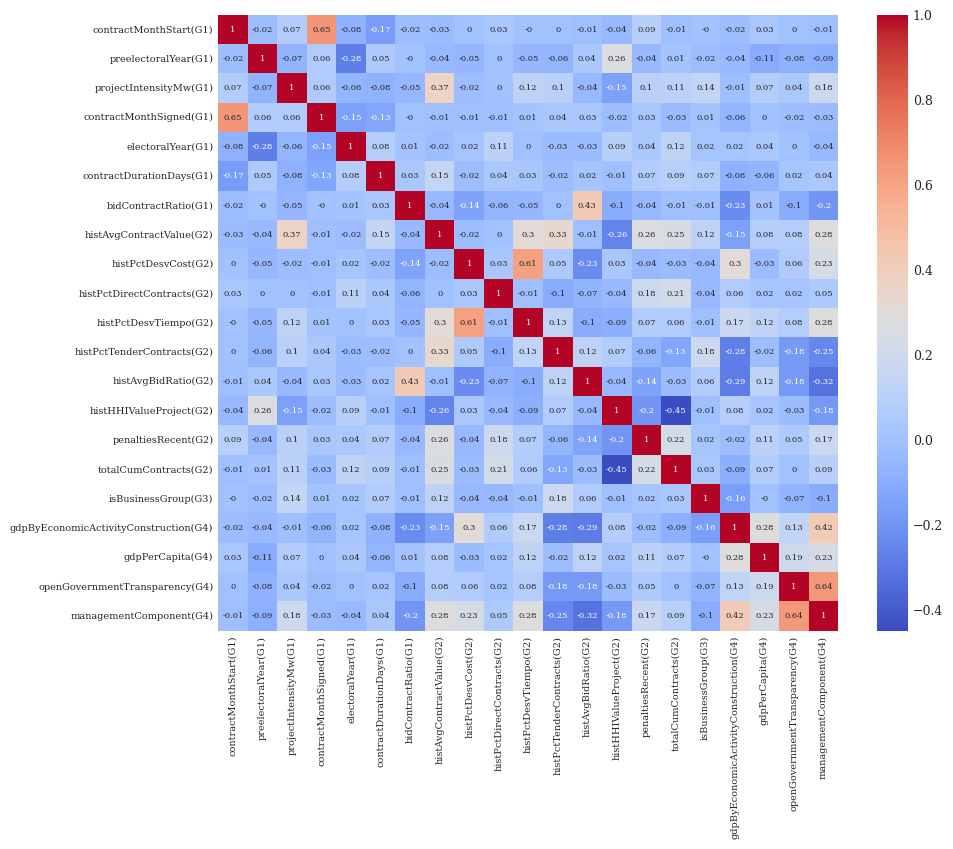

In [320]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[vars_s5].select_dtypes(include=['int64', 'float64']).corr(method='spearman').round(2),
           cmap='coolwarm',
           annot=True,
           annot_kws={'size': 6},
           xticklabels=True,  # Mostrar labels
           yticklabels=True)

# Configurar tamaño después
plt.xticks(fontsize=7)  # Tamaño y rotación eje X
plt.yticks(fontsize=7)
plt.show()

## Cost Deviation Analysis

In [321]:
# Cargar los modelos entrenados para la desviación en costo
lr_results = joblib.load('Models V2/cost_deviation_lr_results.joblib')
rf_results = joblib.load('Models V2/cost_deviation_rf_results.joblib')
xgb_results = joblib.load('Models V2/cost_deviation_xgb_results.joblib')
knn_results = joblib.load('Models V2/cost_deviation_knn_results.joblib')

# Read best parameters
lr_cost_best_params = pd.read_excel('Data/lr_cost_best_params.xlsx')
rf_cost_best_params = pd.read_excel('Data/rf_cost_best_params.xlsx')
xgb_cost_best_params = pd.read_excel('Data/xgb_cost_best_params.xlsx')
knn_cost_best_params = pd.read_excel('Data/knn_cost_best_params.xlsx')

In [322]:
metrics_cost_deviation = pd.read_excel('Data/metrics_cost_deviation.xlsx')
metrics_cost_deviation

,model,stage,setting,precision,recall,f1,accuracy,roc_auc
0,Logistic Regression,S1,Project,32.975207,89.261745,48.159324,36.930984,51.739221
1,Logistic Regression,S2,Project + Owner,44.210526,84.563758,58.064516,59.911894,70.881285
2,Logistic Regression,S3,Project + Contractor,39.782609,81.879195,53.547915,53.377386,65.684772
3,Logistic Regression,S4,Project + Terridata,40.550239,75.838926,52.844895,55.580029,66.265938
4,Logistic Regression,S5,All,44.405594,85.234899,58.390805,60.132159,71.178836
5,Random Forest,S1,Project,35.633484,70.469799,47.332832,48.531571,55.819367
6,Random Forest,S2,Project + Owner,45.333333,83.668904,58.805031,61.527166,72.601313
7,Random Forest,S3,Project + Contractor,41.763943,72.035794,52.873563,57.856094,66.133421
8,Random Forest,S4,Project + Terridata,46.705710,71.364653,56.460177,63.876652,70.360265
9,Random Forest,S5,All,45.223700,83.668904,58.712716,61.380323,73.474163


In [323]:
metrics_cost_deviation.describe()

,precision,recall,f1,accuracy,roc_auc
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,41.708050,75.100671,53.170796,56.688693,65.912391
std,4.565979,11.462511,5.306136,7.198254,7.354268
min,32.975207,39.149888,40.509259,36.930984,51.397049
25%,39.661325,69.574944,50.311436,53.248899,63.878498
50%,41.962979,76.621924,53.584302,58.883994,67.536216
75%,44.610121,83.668904,57.497284,61.417034,71.712785
max,50.687285,89.261745,58.805031,67.767988,73.514260


In [324]:
def plot_results_metrics(df):
  # Crear una matriz pivote para el heatmap
  # Usaremos las métricas como columnas y una combinación de modelo-stage como filas
  df['model_setting'] = df['model'] + ' - ' + df['setting']
  metrics_cols = ['precision', 'recall', 'f1', 'accuracy', 'roc_auc']
  heatmap_data = df.set_index('model_setting')[metrics_cols]

  # Configuración del estilo para artículo académico
  plt.style.use('seaborn-v0_8-whitegrid')
  fig, ax = plt.subplots(figsize=(14, 10))

  # Crear mapa de calor personalizado
  # Colormap de rojo (valores bajos) a verde (valores altos) pasando por amarillo
  colors = ['#d73027', '#f46d43', '#fdae61', '#fee08b', '#e6f598', '#c7d59f', '#9aae5f', '#6d7c32']
  n_bins = 100
  cmap = LinearSegmentedColormap.from_list('red_yellow_olive', colors, N=n_bins)

  # Crear el heatmap
  sns.heatmap(heatmap_data,
              annot=True,
              fmt='.2f',
              cmap=cmap,
              center=50,  # Centrar en 50% para mejor interpretación
              square=False,
              linewidths=0.5,
              cbar_kws={'label': 'Performance Score (%)', 'shrink': 0.8},
              annot_kws={'fontsize': 12, 'fontweight': 'normal'},
              ax=ax)

  # Personalización para estilo académico
  #ax.set_title('Performance Metrics Comparison Across ML Models and Feature Sets',
  #             fontsize=16, fontweight='bold', pad=20)

  # Etiquetas de ejes
  ax.set_xlabel('Performance Metrics', fontsize=14, fontweight='bold')
  ax.set_ylabel('Model - Variable Settings', fontsize=14, fontweight='bold')

  # Rotar etiquetas del eje x para mejor legibilidad
  plt.xticks(rotation=45, ha='right')
  plt.yticks(rotation=0)

  # Ajustar nombres de métricas para el eje x
  metric_labels = ['Precision', 'Recall', 'F1-Score', 'Accuracy', 'ROC-AUC']
  ax.set_xticklabels(metric_labels, fontsize=12)
  ax.set_yticklabels(df['model_setting'].to_list(), fontsize=12)

  # Agregar líneas separadoras entre modelos
  model_boundaries = [0, 5, 10, 15, 20]  # Después de cada grupo de 5 filas
  for boundary in model_boundaries:
      ax.axhline(y=boundary, color='#708090', linewidth=3, alpha=0.8)

  ax.axvline(x=0, color='#708090', linewidth=3, alpha=0.8)
  ax.axvline(x=5, color='#708090', linewidth=3, alpha=0.8)


  # Ajustar el layout
  plt.tight_layout()

  # Mostrar el gráfico
  plt.show()

In [325]:
def plot_performance_models(df):
  # Configuración de estilo científico (optimizado para Colab)
  plt.style.use('default')  # Usar estilo por defecto
  plt.rcParams.update({
      'font.family': 'DejaVu Serif',
      'font.size': 10,
      'axes.labelsize': 11,
      'axes.titlesize': 12,
      'xtick.labelsize': 9,
      'ytick.labelsize': 9,
      'legend.fontsize': 9,
      'figure.titlesize': 14,
      'axes.grid': True,
      'grid.alpha': 0.3,
      'axes.spines.top': False,
      'axes.spines.right': False,
      'axes.linewidth': 0.8,
      'axes.facecolor': 'white',
      'figure.facecolor': 'white'
  })

  # Definir orden de configuraciones
  settings_order = ['Project', 'Project + Owner', 'Project + Contractor', 'Project + Terridata', 'All']
  models = df['model'].unique()  # Obtener modelos dinámicamente

  # Métricas y sus títulos
  metrics_info = {
      'precision': 'Precision (%)',
      'recall': 'Recall (%)',
      'f1': 'F1-Score (%)',
      'accuracy': 'Accuracy (%)',
      'roc_auc': 'ROC-AUC (%)'
  }

  # Crear figura con subplots (3 en primera fila, 2 en segunda fila + espacio para leyenda)
  fig, axes = plt.subplots(2, 3, figsize=(15, 8))
  #fig.suptitle('Performance Metrics Across Different Feature Configurations', fontsize=14, y=0.95)

  # Aplanar axes para facilitar iteración
  axes_flat = axes.flatten()

  # Generar gráficos de línea para cada métrica
  for idx, (metric, title) in enumerate(metrics_info.items()):
      ax = axes_flat[idx]

      # Para cada modelo, extraer y plotear sus valores
      for i, model in enumerate(models):
          model_data = df[df['model'] == model]

          # Crear arrays para x e y
          x_values = []
          y_values = []

          for j, setting in enumerate(settings_order):
              # Buscar el valor para esta configuración
              setting_data = model_data[model_data['setting'] == setting]
              if not setting_data.empty:
                  x_values.append(j)
                  y_values.append(setting_data[metric].iloc[0])

          # Plotear línea para este modelo usando colores automáticos
          ax.plot(x_values, y_values,
                marker='o',
                markersize=5,
                linewidth=2,
                label=model,
                markerfacecolor='white',
                markeredgewidth=1.2)

      # Configurar el subplot
      ax.set_title(title, fontweight='bold', pad=10)
      ax.set_xlabel('Variable Settings', fontweight='normal')
      ax.set_ylabel('Performance (%)', fontweight='normal')
      ax.set_facecolor('white')  # Fondo blanco explícito

      # Configurar eje x
      ax.set_xticks(range(len(settings_order)))
      ax.set_xticklabels([s.replace(' + ', '\n+ ') for s in settings_order],
                        rotation=0, ha='center', fontsize=8)

      # Configurar grilla
      ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
      ax.set_axisbelow(True)

      # Ajustar límites del eje y para mejor visualización
      y_min = min([min(df[df['model'] == model][metric]) for model in models]) - 5
      y_max = max([max(df[df['model'] == model][metric]) for model in models]) + 5
      ax.set_ylim(y_min, y_max)

  # Remover el último subplot y crear leyenda en su lugar
  axes_flat[5].axis('off')
  axes_flat[5].set_facecolor('white')  # Fondo blanco para el área de leyenda

  # Crear leyenda usando los colores automáticos de matplotlib
  handles, labels = axes_flat[0].get_legend_handles_labels()
  axes_flat[5].legend(handles, labels,
                    loc='center',
                    frameon=True,
                    fancybox=False,
                    shadow=False,
                    framealpha=1,
                    edgecolor='black',
                    facecolor='white',
                    title='Classification Models',
                    title_fontsize=11,
                    fontsize=10)

  # Ajustar espaciado entre subplots
  plt.tight_layout()
  plt.subplots_adjust(top=0.90, hspace=0.35, wspace=0.25)

  plt.show()

In [326]:
def plot_efectos_variables(df):
  # Configurar estilo académico
  plt.style.use('seaborn-v0_8-whitegrid')
  plt.rcParams.update({
      'font.size': 9,
      'font.family': 'serif',
      'font.serif': ['Times New Roman', 'DejaVu Serif'],
      'axes.linewidth': 0.8,
      'axes.spines.top': False,
      'axes.spines.right': False,
      'axes.grid': True,
      'grid.alpha': 0,
      'legend.framealpha': 1,
      'legend.edgecolor': 'black',
      'legend.fancybox': False
  })

  # Calcular efectos respecto a la línea base
  metrics = ['precision', 'recall', 'f1', 'accuracy', 'roc_auc']
  metric_labels = ['Precision', 'Recall', 'F1-Score', 'Accuracy', 'ROC-AUC']
  models = df['model'].unique()

  # Crear datos de efectos
  effects_data = []

  for model in models:
      model_data = df[df['model'] == model].copy()
      baseline_row = model_data[model_data['setting'] == 'Project'].iloc[0]
      baselines = {metric: baseline_row[metric] for metric in metrics}

      for _, row in model_data.iterrows():
          if row['setting'] != 'Project':
              for metric in metrics:
                  effect = row[metric] - baselines[metric]
                  effects_data.append({
                      'Model': model,
                      'Setting': row['setting'],
                      'Metric': metric,
                      'Effect': effect,
                      'Baseline': baselines[metric],
                      'Final_Value': row[metric]
                  })

  effects_df = pd.DataFrame(effects_data)

  # Crear mapeo de nombres más limpios
  model_mapping = {
      'Logistic Regression': 'Logistic Regression',
      'Random Forest': 'Random Forest',
      'XGBoost': 'XGBoost',
      'KNN': 'KNN'
  }

  config_mapping = {
      'Project + Owner': 'Owner',
      'Project + Contractor': 'Contractor',
      'Project + Terridata': 'Terridata',
      'All': 'All Variables'
  }

  effects_df['Model_Clean'] = effects_df['Model'].map(model_mapping)
  effects_df['Config_Clean'] = effects_df['Setting'].map(config_mapping)

  # Definir orden de modelos y configuraciones
  models_order = ['KNN','XGBoost','Random Forest','Logistic Regression']
  configs_order = ['All Variables', 'Terridata', 'Contractor', 'Owner']

  # Crear el gráfico principal
  fig, axes = plt.subplots(1, 5, figsize=(22, 16), sharey=True)
  #fig.suptitle('Effect of Additional Features on Model Performance\n(Relative to Baseline Configuration)',
  #             fontsize=16, fontweight='bold', y=0.95)

  # Paleta de colores
  colors = ['#2C3E50', '#34495E', '#7F8C8D', '#BDC3C7']
  color_map = {config: colors[i] for i, config in enumerate(configs_order)}

  # Preparar etiquetas y posiciones del eje Y
  y_labels = []
  y_positions = []
  y_pos = 0
  # Crear etiquetas para cada combinación modelo-configuración
  for model in models_order:
    for config in configs_order:
      if config == 'All Variables':
        y_labels.append(f'{model} \n {config}')
        y_positions.append(y_pos)
        y_pos += 1
      else:
        y_labels.append(f'{model}\n+ {config}')
        y_positions.append(y_pos)
        y_pos += 1
    y_pos += 1  # Espacio entre modelos

  # Procesar cada métrica
  for i, (metric, metric_label) in enumerate(zip(metrics, metric_labels)):
      ax = axes[i]

      # Filtrar datos para esta métrica
      metric_data = effects_df[effects_df['Metric'] == metric].copy()

      # Preparar datos ordenados
      plot_data = []
      y_pos = 0

      for model in models_order:
          model_data = metric_data[metric_data['Model_Clean'] == model]

          for config in configs_order:
              config_data = model_data[model_data['Config_Clean'] == config]

              if not config_data.empty:
                  effect = config_data['Effect'].iloc[0]
                  plot_data.append({
                      'y_pos': y_pos,
                      'effect': effect,
                      'config': config,
                      'model': model
                  })
              y_pos += 1
          y_pos += 1  # Espacio entre modelos

      # Crear barras horizontales
      if plot_data:
          y_positions_plot = [d['y_pos'] for d in plot_data]
          effects_values = [d['effect'] for d in plot_data]
          bar_colors = [color_map[d['config']] for d in plot_data]

          bars = ax.barh(y_positions_plot, effects_values, height=0.7,
                        color=bar_colors, alpha=0.8, edgecolor='black', linewidth=0.5)

          # Agregar valores en las barras
          for bar, value in zip(bars, effects_values):
              width = bar.get_width()
              x_offset = 1.5 if width >= 0 else -1.5
              ax.text(width + x_offset, bar.get_y() + bar.get_height()/2,
                    f'{value:+.1f}', ha='left' if width >= 0 else 'right',
                    va='center', fontsize=14, fontweight='bold')

      # Configurar título y ejes
      ax.set_title(f'{metric_label}', fontsize=16, fontweight='bold', pad=20)
      ax.set_xlabel('Effect Size (percentage points)', fontsize=14)
      ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.8)

      # Configurar etiquetas Y solo en el primer subplot
      if i == 0:
          ax.set_yticks(y_positions)
          ax.set_yticklabels(y_labels, fontsize=16, ha='right')
          ax.set_ylabel('Model + Variable Settings', fontsize=16, fontweight='bold')

      # Ajustar límites
      if plot_data:
          max_abs_effect = max(abs(d['effect']) for d in plot_data)
          ax.set_xlim(-max_abs_effect * 1.5, max_abs_effect * 1.5)

      # Configurar límites Y
      ax.set_ylim(-1, max(y_positions) + 1)

      # Grid
      #ax.grid(True, alpha=0.3, axis='x')
      #ax.set_axisbelow(True)

      # Líneas separadoras entre modelos
      separator_positions = [4, 9, 14]
      for sep_pos in separator_positions:
          if sep_pos <= max(y_positions):
              ax.axhline(y=sep_pos, color='gray', linestyle='--', alpha=0.4, linewidth=1)

  # Crear leyenda
  #legend_elements = [plt.Rectangle((0,0),1,1, facecolor=color_map[config],
  #                                edgecolor='black', alpha=0.8, label=config)
  #                  for config in configs_order]

  #fig.legend(handles=legend_elements, loc='lower center',
  #          bbox_to_anchor=(0.5, 0.02), ncol=4,
  #          frameon=True, edgecolor='black', fontsize=11)

  plt.tight_layout()
  plt.subplots_adjust(bottom=0.15, top=0.88, left=0.12)
  plt.show()

### Análisis Descriptivo

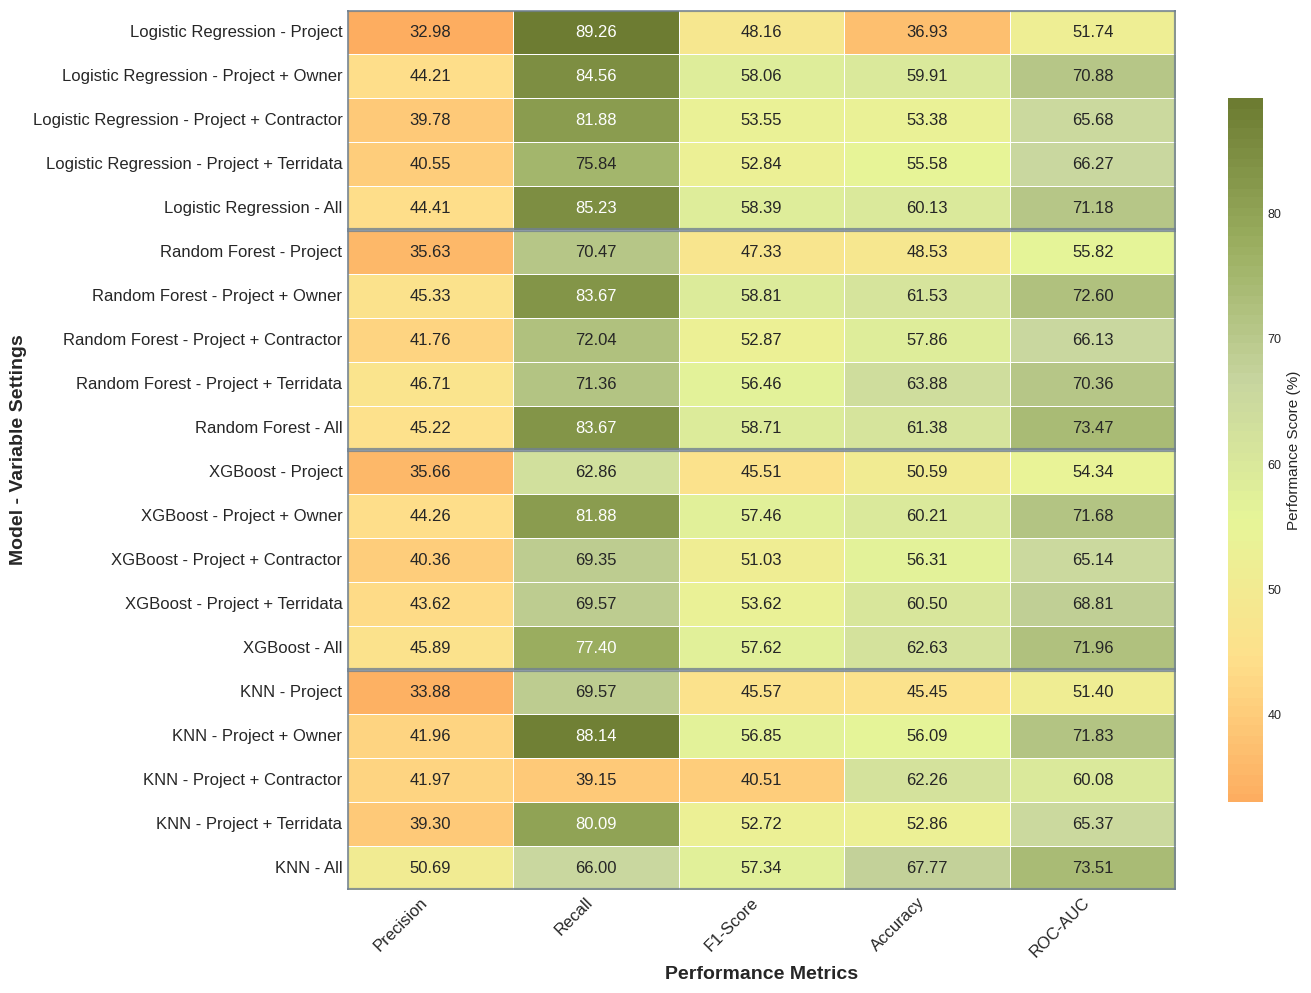

In [327]:
plot_results_metrics(metrics_cost_deviation)

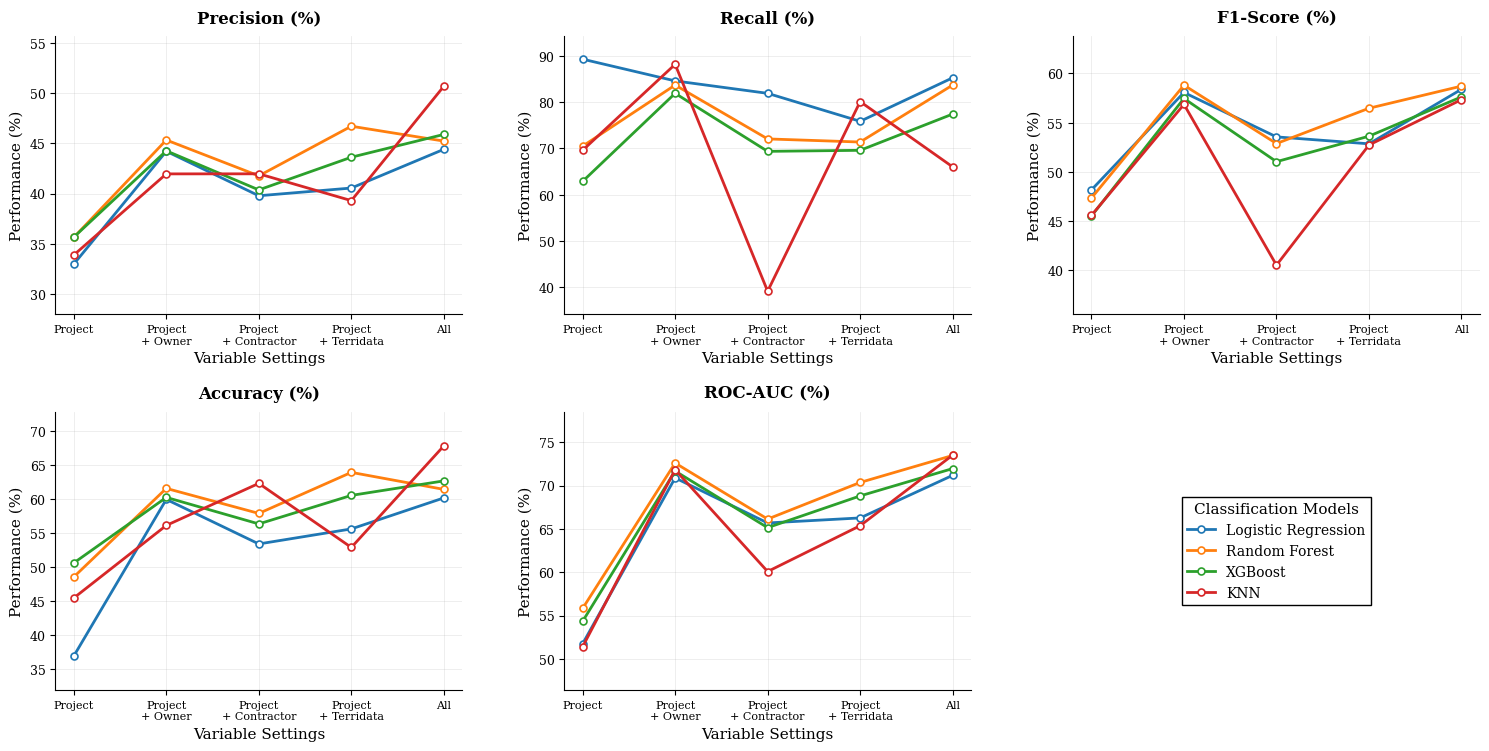

In [328]:
plot_performance_models(metrics_cost_deviation)

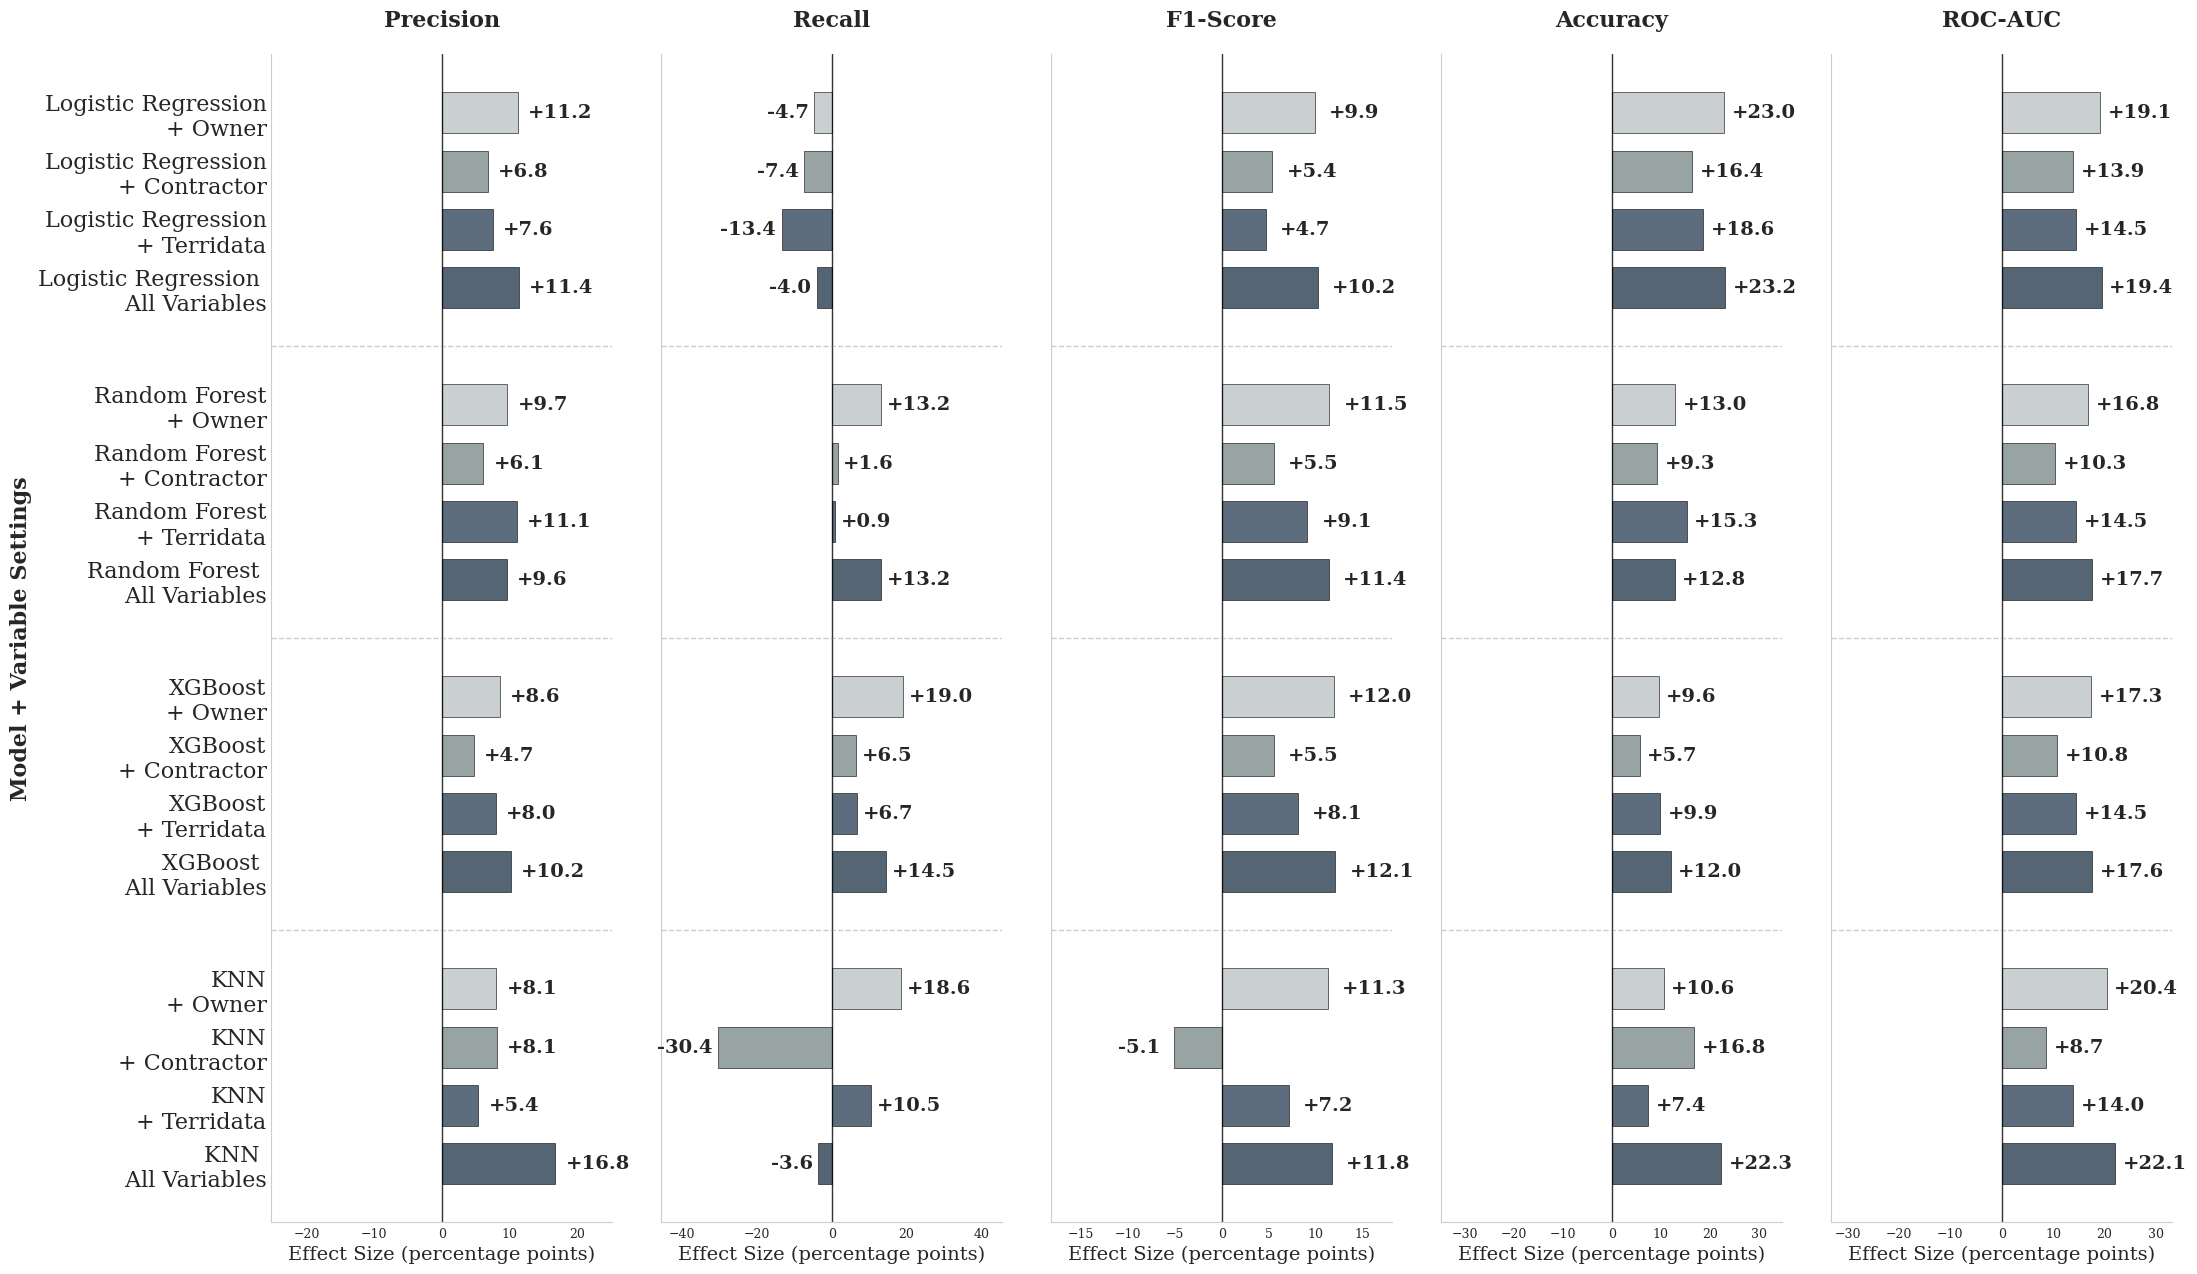

In [329]:
plot_efectos_variables(metrics_cost_deviation)

In [330]:
metrics_cost_deviation.set_index(['model', 'stage']).to_latex(
    index=True,
    float_format=lambda x: "{:.2f}".format(x)
)

'\\begin{tabular}{lllrrrrrl}\n\\toprule\n &  & setting & precision & recall & f1 & accuracy & roc_auc & model_setting \\\\\nmodel & stage &  &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{5}{*}{Logistic Regression} & S1 & Project & 32.98 & 89.26 & 48.16 & 36.93 & 51.74 & Logistic Regression - Project \\\\\n & S2 & Project + Owner & 44.21 & 84.56 & 58.06 & 59.91 & 70.88 & Logistic Regression - Project + Owner \\\\\n & S3 & Project + Contractor & 39.78 & 81.88 & 53.55 & 53.38 & 65.68 & Logistic Regression - Project + Contractor \\\\\n & S4 & Project + Terridata & 40.55 & 75.84 & 52.84 & 55.58 & 66.27 & Logistic Regression - Project + Terridata \\\\\n & S5 & All & 44.41 & 85.23 & 58.39 & 60.13 & 71.18 & Logistic Regression - All \\\\\n\\cline{1-9}\n\\multirow[t]{5}{*}{Random Forest} & S1 & Project & 35.63 & 70.47 & 47.33 & 48.53 & 55.82 & Random Forest - Project \\\\\n & S2 & Project + Owner & 45.33 & 83.67 & 58.81 & 61.53 & 72.60 & Random Forest - Project + Owner \\\\\n & S3 & Project 

### Análisis Inferencial

In [331]:
# Diseño experimental con validación cruzada
# results_cost_dev = [lr_results, rf_results, xgb_results, knn_results]
# #results_cost_dev = [lr_results]
# modelos = {'Logistic Regression': LogisticRegression(max_iter=10000, solver='liblinear', random_state=42),
#            'Random Forest': RandomForestClassifier(random_state=42),
#            'XGBoost': XGBClassifier(random_state=42),
#            'KNN': KNeighborsClassifier()}
# results_cv_cost_models = pd.DataFrame()
# stratified_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# for res in results_cost_dev:
#   for i,s in enumerate(res.keys()):
#     print(f"Setting:{s}")
#     print(f"Modelo: {res[s]['metrics']['model']}")
#     model_name = res[s]['metrics']['model']
#     model = modelos[model_name]
#     params = res[s]['best_params']

#     X = df[set_vars[i]].copy()
#     y = df['haveCostDeviation(G5)'].copy()

#     numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
#     categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


#     # Crear transformadores para cada tipo de característica
#     numeric_transformer = Pipeline(steps=[
#         ('imputer', SimpleImputer(strategy='median')),
#         ('scaler', StandardScaler())
#     ])

#     categorical_transformer = Pipeline(steps=[
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('onehot', OneHotEncoder(handle_unknown='ignore'))
#     ])

#     # Preprocesamiento de características
#     preprocessor = ColumnTransformer(
#         transformers=[
#             ('num', numeric_transformer, numeric_features),
#             ('cat', categorical_transformer, categorical_features)
#         ]
#     )

#     resampler = SMOTEENN(sampling_strategy='auto', random_state=42)

#     base_pipeline = ImbPipeline([
#           ('preprocessor', preprocessor),
#           ('resampler', resampler),
#           ('classifier', model)
#       ])
#     # Configurar el modelo con los parámetros sugeridos
#     for param_name, param_value in params.items():
#       setattr(base_pipeline.named_steps['classifier'], param_name, param_value)
#     # Entrenar el modelo

#     scores = cross_validate(base_pipeline, X, y, cv=stratified_cv,
#                    scoring=['roc_auc','accuracy','f1','recall','precision'])

#     scores = pd.DataFrame(scores)
#     scores['model'] = model_name
#     scores['setting'] = s

#     results_cv_cost_models = pd.concat([results_cv_cost_models, scores], axis=0)
#     #base_pipeline.fit(X, y)
#     # Realizar predicciones
#     #y_pred = base_pipeline.predict(X)
#     # accuracy
#     #accuracy = accuracy_score(y, y_pred)
#     #print(f"Accuracy: {accuracy}")
# results_cv_cost_models.to_csv('Data/doe_results_cv_cost_models.csv', index=False)

In [332]:
# Multiplicar por 100 todas las métricas
results_cv_cost_models = pd.read_csv('Data/doe_results_cv_cost_models.csv')
metrics = ['test_roc_auc', 'test_accuracy', 'test_f1', 'test_recall', 'test_precision']
for i in metrics:
  results_cv_cost_models[i] = np.round(results_cv_cost_models[i]*100,2)
results_cv_cost_models.groupby(['model','setting']).mean()

fit_time  score_time  test_roc_auc  \
model               setting                                       
KNN                 S1       0.124675    0.160228     54.726667   
                    S2       0.186598    0.543202     71.246667   
                    S3       1.138769    0.595112     60.043333   
                    S4       0.193975    0.293233     65.040000   
                    S5       1.511869    0.835573     71.973333   
Logistic Regression S1       0.211739    0.038759     52.936667   
                    S2       0.209919    0.042283     70.936667   
                    S3       1.062890    0.048504     65.130000   
                    S4       0.149052    0.041405     64.043333   
                    S5       2.058609    0.068666     71.720000   
Random Forest       S1       1.262677    0.194723     57.123333   
                    S2       4.772111    0.375659     72.540000   
                    S3       6.895543    0.507982     65.573333   
                    S4       0.782248    0.102330     67.536667   
                    S5       7.557975    0.471162     73.490000   
XGBoost             S1       0.287903    0.051457     56.973333   
                    S2       0.705240    0.061592     71.620000   
                    S3       1.366651    0.082999     64.136667   
                    S4       0.300143    0.052649     67.550000   
                    S5       2.954308    0.094551     73.090000   

                             test_accuracy    test_f1  test_recall  \
model               setting                                          
KNN                 S1           48.216667  46.440000    68.550000   
                    S2           56.546667  56.480000    86.020000   
                    S3           59.583333  43.653333    47.850000   
                    S4           51.716667  52.503333    81.383333   
                    S5           67.010000  54.046667    59.410000   
Logistic Regression S1           38.080000  48.436667    88.776667   
                    S2           60.136667  57.143333    81.116667   
                    S3           53.216667  53.220000    81.120000   
                    S4           53.436667  51.033333    73.993333   
                    S5           60.380000  57.606667    82.190000   
Random Forest       S1           52.843333  46.096667    61.760000   
                    S2           61.440000  57.940000    81.050000   
                    S3           56.256667  51.793333    71.706667   
                    S4           61.260000  52.180000    64.450000   
                    S5           61.723333  57.983333    80.576667   
XGBoost             S1           50.286667  47.173333    67.810000   
                    S2           62.033333  56.836667    76.343333   
                    S3           54.430000  50.926667    72.110000   
                    S4           60.026667  53.710000    70.766667   
                    S5           60.863333  57.890000    82.056667   

                             test_precision  
model               setting                  
KNN                 S1            35.183333  
                    S2            42.053333  
                    S3            40.340000  
                    S4            38.760000  
                    S5            49.786667  
Logistic Regression S1            33.316667  
                    S2            44.133333  
                    S3            39.626667  
                    S4            38.950000  
                    S5            44.366667  
Random Forest       S1            36.933333  
                    S2            45.126667  
                    S3            40.560000  
                    S4            43.843333  
                    S5            45.296667  
XGBoost             S1            36.210000  
                    S2            45.313333  
                    S3            39.403333  
                    S4            43.293333  
                    S5            44.730000

In [333]:
# Función para formatear p-valores
def format_pvalue(p):
    """Formatear p-valores para presentación"""
    if pd.isna(p):
        return 'N/A'
    elif p < 0.001:
        return '< 0.001***'
    elif p < 0.01:
        return f'{p:.3f}**'
    elif p < 0.05:
        return f'{p:.3f}*'
    else:
        return f'{p:.3f}'

# Función para formatear F-estadísticos
def format_f_stat(f):
    """Formatear F-estadísticos"""
    if pd.isna(f):
        return 'N/A'
    else:
        return f'{f:.2f}'

In [334]:
# Realizar ANOVA de dos factores y consolidar resultados
metrics = ['test_roc_auc', 'test_accuracy', 'test_f1', 'test_recall', 'test_precision']
anova_consolidated = pd.DataFrame()

lm_anova_cost_dev = {}

#print("Realizando ANOVA para todas las métricas...")
#print("="*80)

for metric in metrics:
    #print(f"Procesando métrica: {metric}")

    # Realizar ANOVA
    model_anova = ols(f'{metric} ~ C(setting) + C(model)', data=results_cv_cost_models).fit()
    lm_anova_cost_dev[metric] = model_anova
    anova_results = anova_lm(model_anova, typ=2)

    # Extraer resultados (excluyendo la fila de residuos)
    temp = anova_results[['F', 'PR(>F)']].iloc[:-1].reset_index(names='Factor')
    temp['Metric'] = metric

    # Consolidar
    anova_consolidated = pd.concat([anova_consolidated, temp], axis=0, ignore_index=True)

    # Imprimir resultados individuales (opcional)
    #print(f"\nResultados ANOVA para {metric}:")
    #print(anova_results)
    #print("-" * 50)

# Reorganizar DataFrame para mejor presentación
anova_consolidated = anova_consolidated[['Metric', 'Factor', 'F', 'PR(>F)']]

model_names_anova = ['ROC AUC', 'Accuracy', 'F1', 'Recall', 'Precision']
# Consolidar modelos linales
lm_anova_consolidated = summary_col([lm_anova_cost_dev['test_roc_auc'],
                                     lm_anova_cost_dev['test_accuracy'],
                                     lm_anova_cost_dev['test_f1'],
                                     lm_anova_cost_dev['test_recall'],
                                     lm_anova_cost_dev['test_precision']],
                                     model_names=model_names_anova,
                                    stars=True,  # Mostrar asteriscos de significancia
                                    float_format='%.3f',  # Formato de decimales
                                    info_dict={
                                        'N': lambda x: f"{int(x.nobs)}",
                                        'R2': lambda x: f"{x.rsquared:.3f}",
                                        'Adj. R2': lambda x: f"{x.rsquared_adj:.3f}",
                                        'F-stat': lambda x: f"{x.fvalue:.2f}",
                                        'Prob(F)': lambda x: f"{x.f_pvalue:.3f}"
                                    }
                                )

# Crear tabla pivotada para mejor visualización
print("\n" + "="*80)
print("TABLA CONSOLIDADA DE RESULTADOS ANOVA")
print("="*80)

# Opción 1: Tabla larga (una fila por métrica-factor)
anova_display = anova_consolidated.copy()
anova_display['F_formatted'] = anova_display['F'].apply(format_f_stat)
anova_display['p_formatted'] = anova_display['PR(>F)'].apply(format_pvalue)
anova_display['F_p_combined'] = anova_display['F_formatted'] + ' (' + anova_display['p_formatted'] + ')'

print("\nFormato tabla larga:")
print(anova_display[['Metric', 'Factor', 'F_formatted','p_formatted']].to_string(index=False))


TABLA CONSOLIDADA DE RESULTADOS ANOVA

Formato tabla larga:
        Metric     Factor F_formatted p_formatted
  test_roc_auc C(setting)      236.40  < 0.001***
  test_roc_auc   C(model)       10.31  < 0.001***
 test_accuracy C(setting)       34.47  < 0.001***
 test_accuracy   C(model)        7.73  < 0.001***
       test_f1 C(setting)       58.83  < 0.001***
       test_f1   C(model)        7.06  < 0.001***
   test_recall C(setting)        3.62      0.011*
   test_recall   C(model)        5.56     0.002**
test_precision C(setting)       67.51  < 0.001***
test_precision   C(model)        4.74     0.005**


In [335]:
print(lm_anova_consolidated)


                                 ROC AUC   Accuracy     F1      Recall  Precision
---------------------------------------------------------------------------------
Intercept                       54.175*** 47.497*** 45.007*** 66.415*** 35.274***
                                (0.568)   (1.240)   (0.723)   (3.255)   (0.630)  
C(setting)[T.S2]                16.146*** 12.682*** 10.063*** 9.408**   8.746*** 
                                (0.636)   (1.386)   (0.808)   (3.640)   (0.705)  
C(setting)[T.S3]                8.281***  8.515***  2.862***  -3.527    4.572*** 
                                (0.636)   (1.386)   (0.808)   (3.640)   (0.705)  
C(setting)[T.S4]                10.602*** 9.253***  5.320***  0.924     5.801*** 
                                (0.636)   (1.386)   (0.808)   (3.640)   (0.705)  
C(setting)[T.S5]                17.128*** 15.137*** 9.845***  4.334     10.634***
                                (0.636)   (1.386)   (0.808)   (3.640)   (0.705)  
C(model)[T.Logi

In [336]:
anova_display['Metric'].replace({'test_roc_auc': 'ROC AUC', 'test_accuracy': 'Accuracy', 'test_f1': 'F1', 'test_recall': 'Recall', 'test_precision': 'Precision'}, inplace=True)
anova_display['Factor'].replace({'C(setting)': 'Setting', 'C(model)': 'Model'}, inplace=True)
anova_display.rename(columns={'F_formatted': 'Fo', 'p_formatted':'p'}, inplace=True)
anova_display[['Metric','Factor','Fo','p']].set_index(['Metric','Factor']).to_latex(
    index=True,
    float_format=lambda x: "{:.2f}".format(x)
)

'\\begin{tabular}{llll}\n\\toprule\n &  & Fo & p \\\\\nMetric & Factor &  &  \\\\\n\\midrule\n\\multirow[t]{2}{*}{ROC AUC} & Setting & 236.40 & < 0.001*** \\\\\n & Model & 10.31 & < 0.001*** \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{Accuracy} & Setting & 34.47 & < 0.001*** \\\\\n & Model & 7.73 & < 0.001*** \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{F1} & Setting & 58.83 & < 0.001*** \\\\\n & Model & 7.06 & < 0.001*** \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{Recall} & Setting & 3.62 & 0.011* \\\\\n & Model & 5.56 & 0.002** \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{Precision} & Setting & 67.51 & < 0.001*** \\\\\n & Model & 4.74 & 0.005** \\\\\n\\cline{1-4}\n\\bottomrule\n\\end{tabular}\n'

In [337]:
lm_anova_consolidated.as_latex()

'\\begin{table}\n\\caption{}\n\\label{}\n\\begin{center}\n\\begin{tabular}{llllll}\n\\hline\n                                & ROC AUC   & Accuracy  & F1        & Recall    & Precision  \\\\\n\\hline\nIntercept                       & 54.175*** & 47.497*** & 45.007*** & 66.415*** & 35.274***  \\\\\n                                & (0.568)   & (1.240)   & (0.723)   & (3.255)   & (0.630)    \\\\\nC(setting)[T.S2]                & 16.146*** & 12.682*** & 10.063*** & 9.408**   & 8.746***   \\\\\n                                & (0.636)   & (1.386)   & (0.808)   & (3.640)   & (0.705)    \\\\\nC(setting)[T.S3]                & 8.281***  & 8.515***  & 2.862***  & -3.527    & 4.572***   \\\\\n                                & (0.636)   & (1.386)   & (0.808)   & (3.640)   & (0.705)    \\\\\nC(setting)[T.S4]                & 10.602*** & 9.253***  & 5.320***  & 0.924     & 5.801***   \\\\\n                                & (0.636)   & (1.386)   & (0.808)   & (3.640)   & (0.705)    \\\\\nC(setti

In [338]:
print(model_anova.summary())

                            OLS Regression Results                            
Dep. Variable:         test_precision   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     40.61
Date:                Fri, 10 Oct 2025   Prob (F-statistic):           6.82e-19
Time:                        18:53:12   Log-Likelihood:                -113.61
No. Observations:                  60   AIC:                             243.2
Df Residuals:                      52   BIC:                             260.0
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
Intercept 

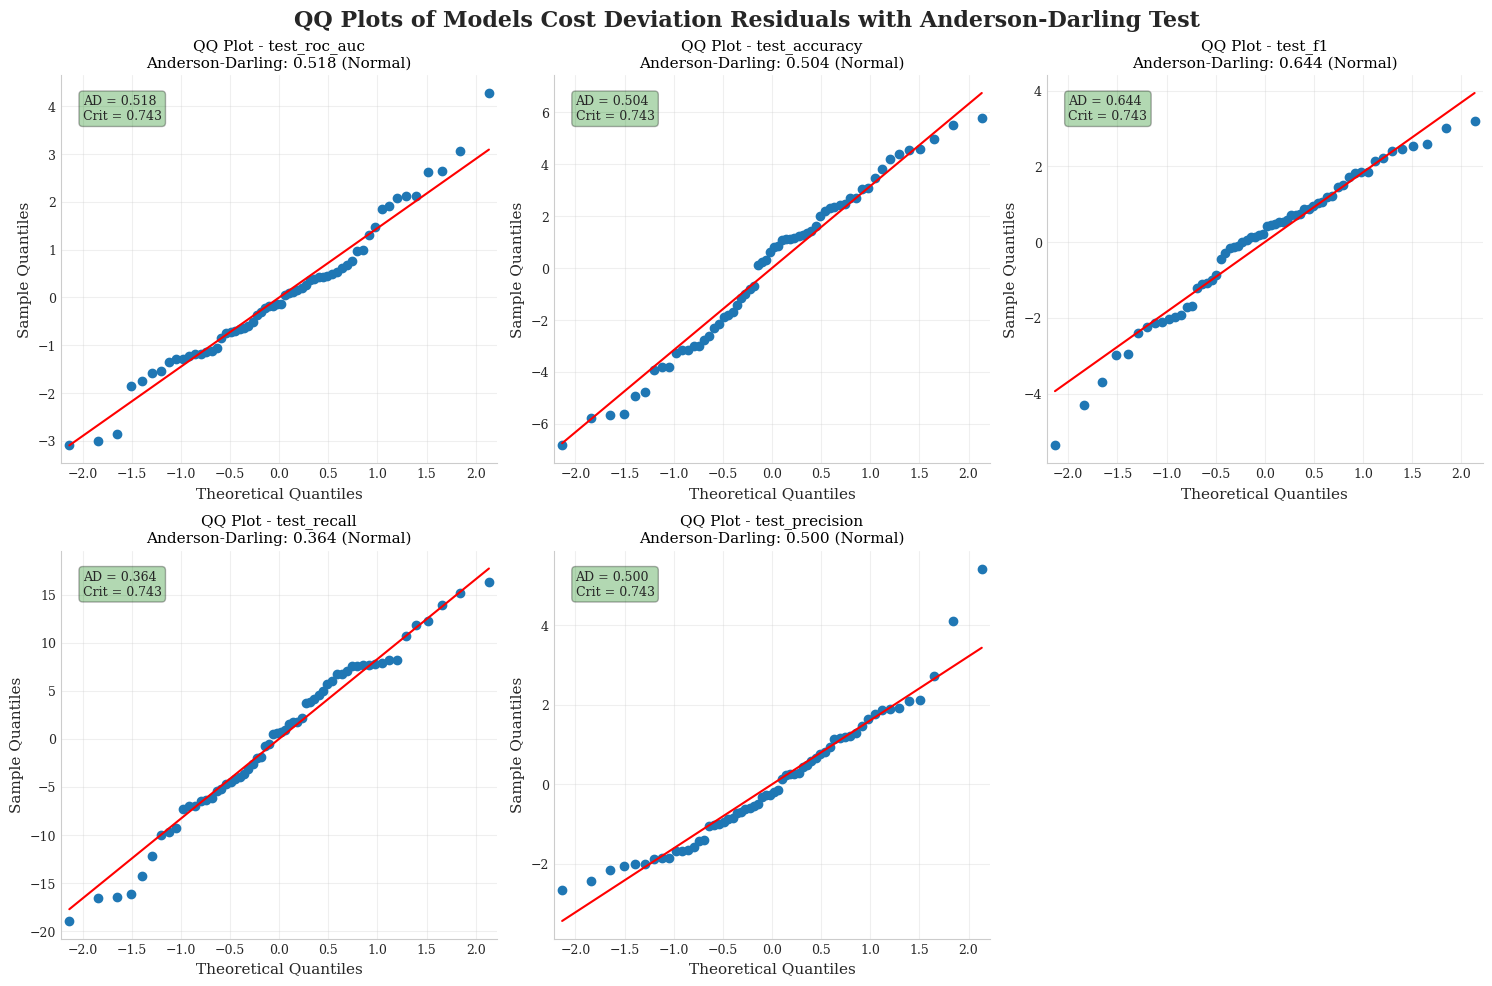

In [339]:
# QQ plots for all models and metrics in subplots (2 rows, 3 columns)

# Crear figura con subplots 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('QQ Plots of Models Cost Deviation Residuals with Anderson-Darling Test', fontsize=16, fontweight='bold')

# Aplanar el array de axes para facilitar la iteración
axes_flat = axes.flatten()

# Iterar sobre cada métrica y crear QQ plot en cada subplot
for i, metric in enumerate(metrics):
    if i < len(axes_flat):  # Verificar que no excedamos el número de subplots
        ax = axes_flat[i]
        residuals = lm_anova_cost_dev[metric].resid

        # Crear QQ plot
        sm.qqplot(residuals, line='s', ax=ax)

        # Realizar prueba de Anderson-Darling para normalidad
        ad_stat, ad_critical_vals, ad_p_value = stats.anderson(residuals, dist='norm')

        # Determinar si rechazamos H0 (los datos no son normales)
        # Usando el nivel de significancia de 5% (índice 2 en critical values)
        alpha_level = 0.05
        critical_val_5pct = ad_critical_vals[2]  # Valor crítico para 5%

        if ad_stat > critical_val_5pct:
            normality_result = "Non-Normal"
            color = 'red'
        else:
            normality_result = "Normal"
            color = 'green'

        # Título con información de la prueba
        ax.set_title(f'QQ Plot - {metric}\nAnderson-Darling: {ad_stat:.3f} ({normality_result})',
                    fontsize=11, color='black')

        # Añadir texto con el estadístico en la esquina
        ax.text(0.05, 0.95, f'AD = {ad_stat:.3f}\nCrit = {critical_val_5pct:.3f}',
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))

        ax.grid(True, alpha=0.3)

# Ocultar subplots vacíos si hay menos de 6 métricas
for i in range(len(metrics), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.show()

## Time Deviation Analysis

### Análisis Descriptivo

In [340]:
# Read best parameters
lr_time_best_params = pd.read_excel('Data/lr_time_best_params.xlsx')
rf_time_best_params = pd.read_excel('Data/rf_time_best_params.xlsx')
xgb_time_best_params = pd.read_excel('Data/xgb_time_best_params.xlsx')
knn_time_best_params = pd.read_excel('Data/knn_time_best_params.xlsx')

In [341]:
# Cargar resultados de las metricas de los modelos para desviaciones en tiempo
metrics_time_deviation = pd.read_excel('Data/metrics_time_deviation.xlsx')
metrics_time_deviation

,model,stage,setting,precision,recall,f1,accuracy,roc_auc
0,Logistic Regression,S1,Project,53.333333,65.769806,58.902276,54.919236,56.334539
1,Logistic Regression,S2,Project + Owner,66.521106,68.310912,67.404130,67.547724,74.301956
2,Logistic Regression,S3,Project + Contractor,59.540890,62.032885,60.761347,60.646109,65.420487
3,Logistic Regression,S4,Project + Terridata,60.410095,57.249626,58.787414,60.572687,63.449032
4,Logistic Regression,S5,All,68.155620,70.702541,69.405723,69.383260,75.427023
5,Random Forest,S1,Project,54.484605,60.837070,57.485876,55.800294,58.888156
6,Random Forest,S2,Project + Owner,68.476621,67.862481,68.168168,68.869310,77.514737
7,Random Forest,S3,Project + Contractor,58.831522,64.723468,61.637011,60.425844,66.273993
8,Random Forest,S4,Project + Terridata,63.829787,67.264574,65.502183,65.198238,70.231355
9,Random Forest,S5,All,69.284712,73.841555,71.490593,71.071953,77.856507


In [342]:
metrics_time_deviation.describe()

,precision,recall,f1,accuracy,roc_auc
count,20.000000,20.000000,20.000000,20.000000,20.000000
mean,62.134986,64.753363,63.364933,63.208517,68.183269
std,6.083679,6.218289,5.915753,6.103302,7.794069
min,53.333333,51.420030,52.760736,54.625551,56.334539
25%,56.570426,60.351271,58.654780,57.819383,62.991138
50%,62.113879,66.367713,63.495384,62.885463,67.638266
75%,68.235870,69.394619,68.527901,68.997797,75.781356
max,70.030120,74.289985,71.872740,71.439060,77.856507


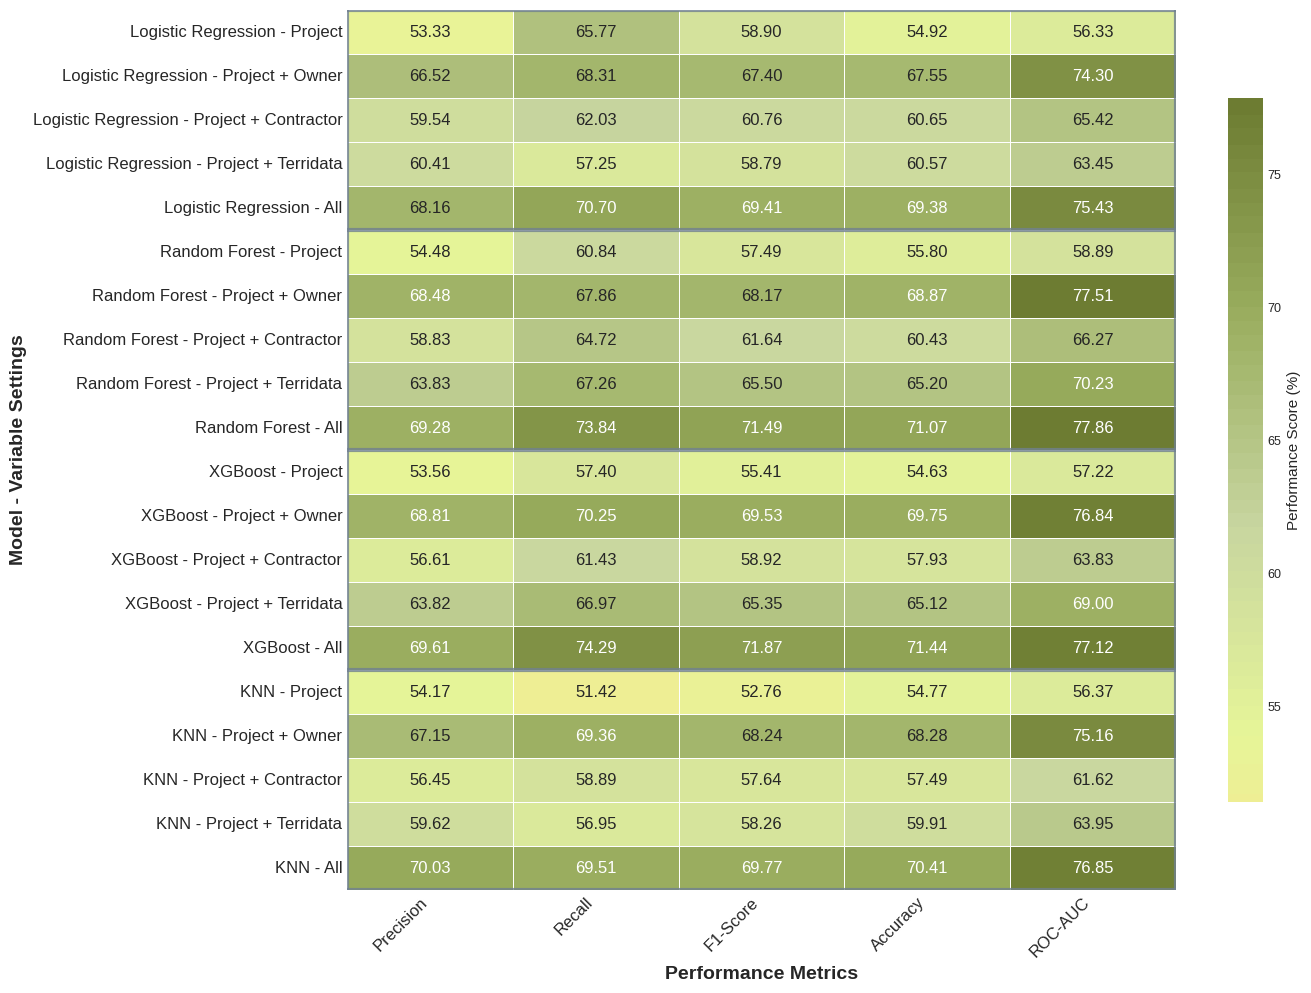

In [343]:
plot_results_metrics(metrics_time_deviation)

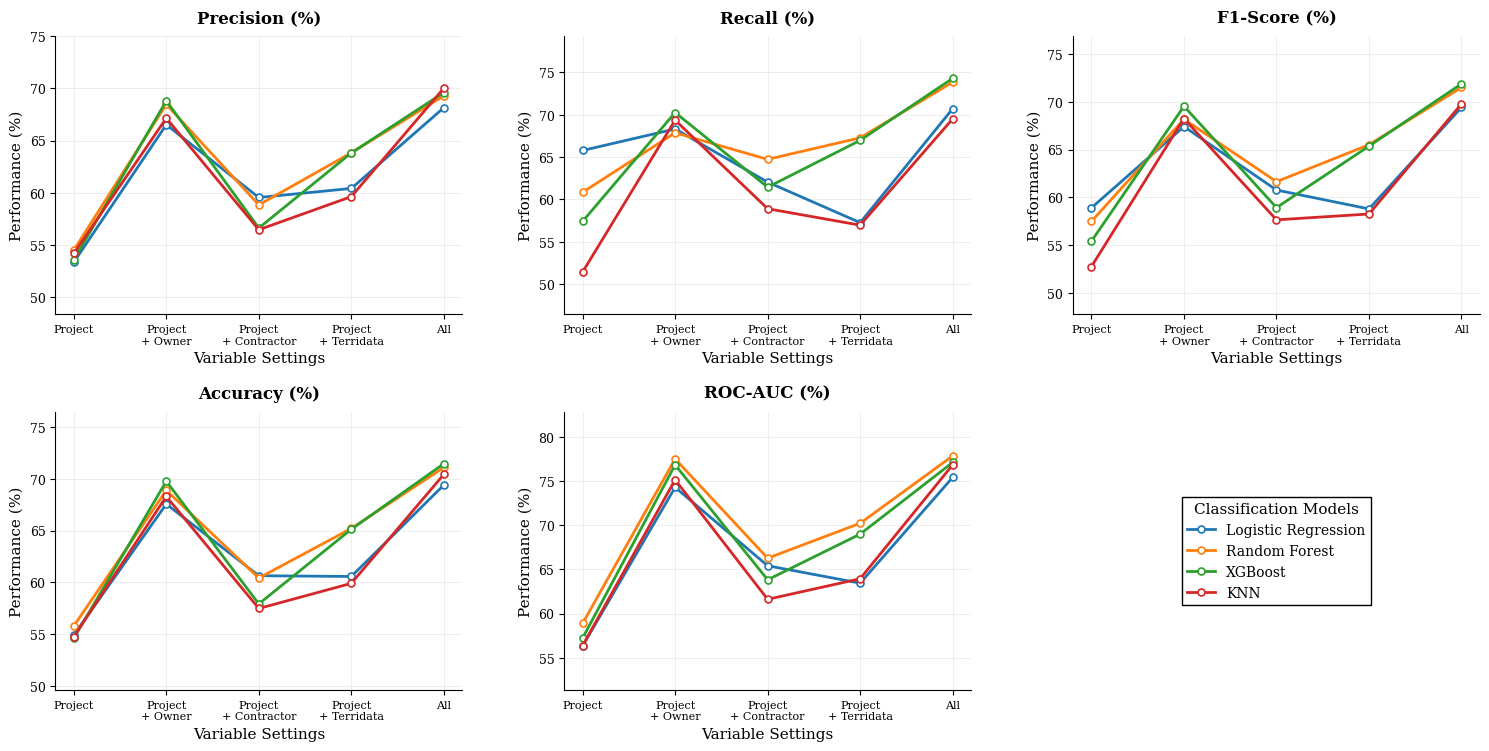

In [344]:
plot_performance_models(metrics_time_deviation)

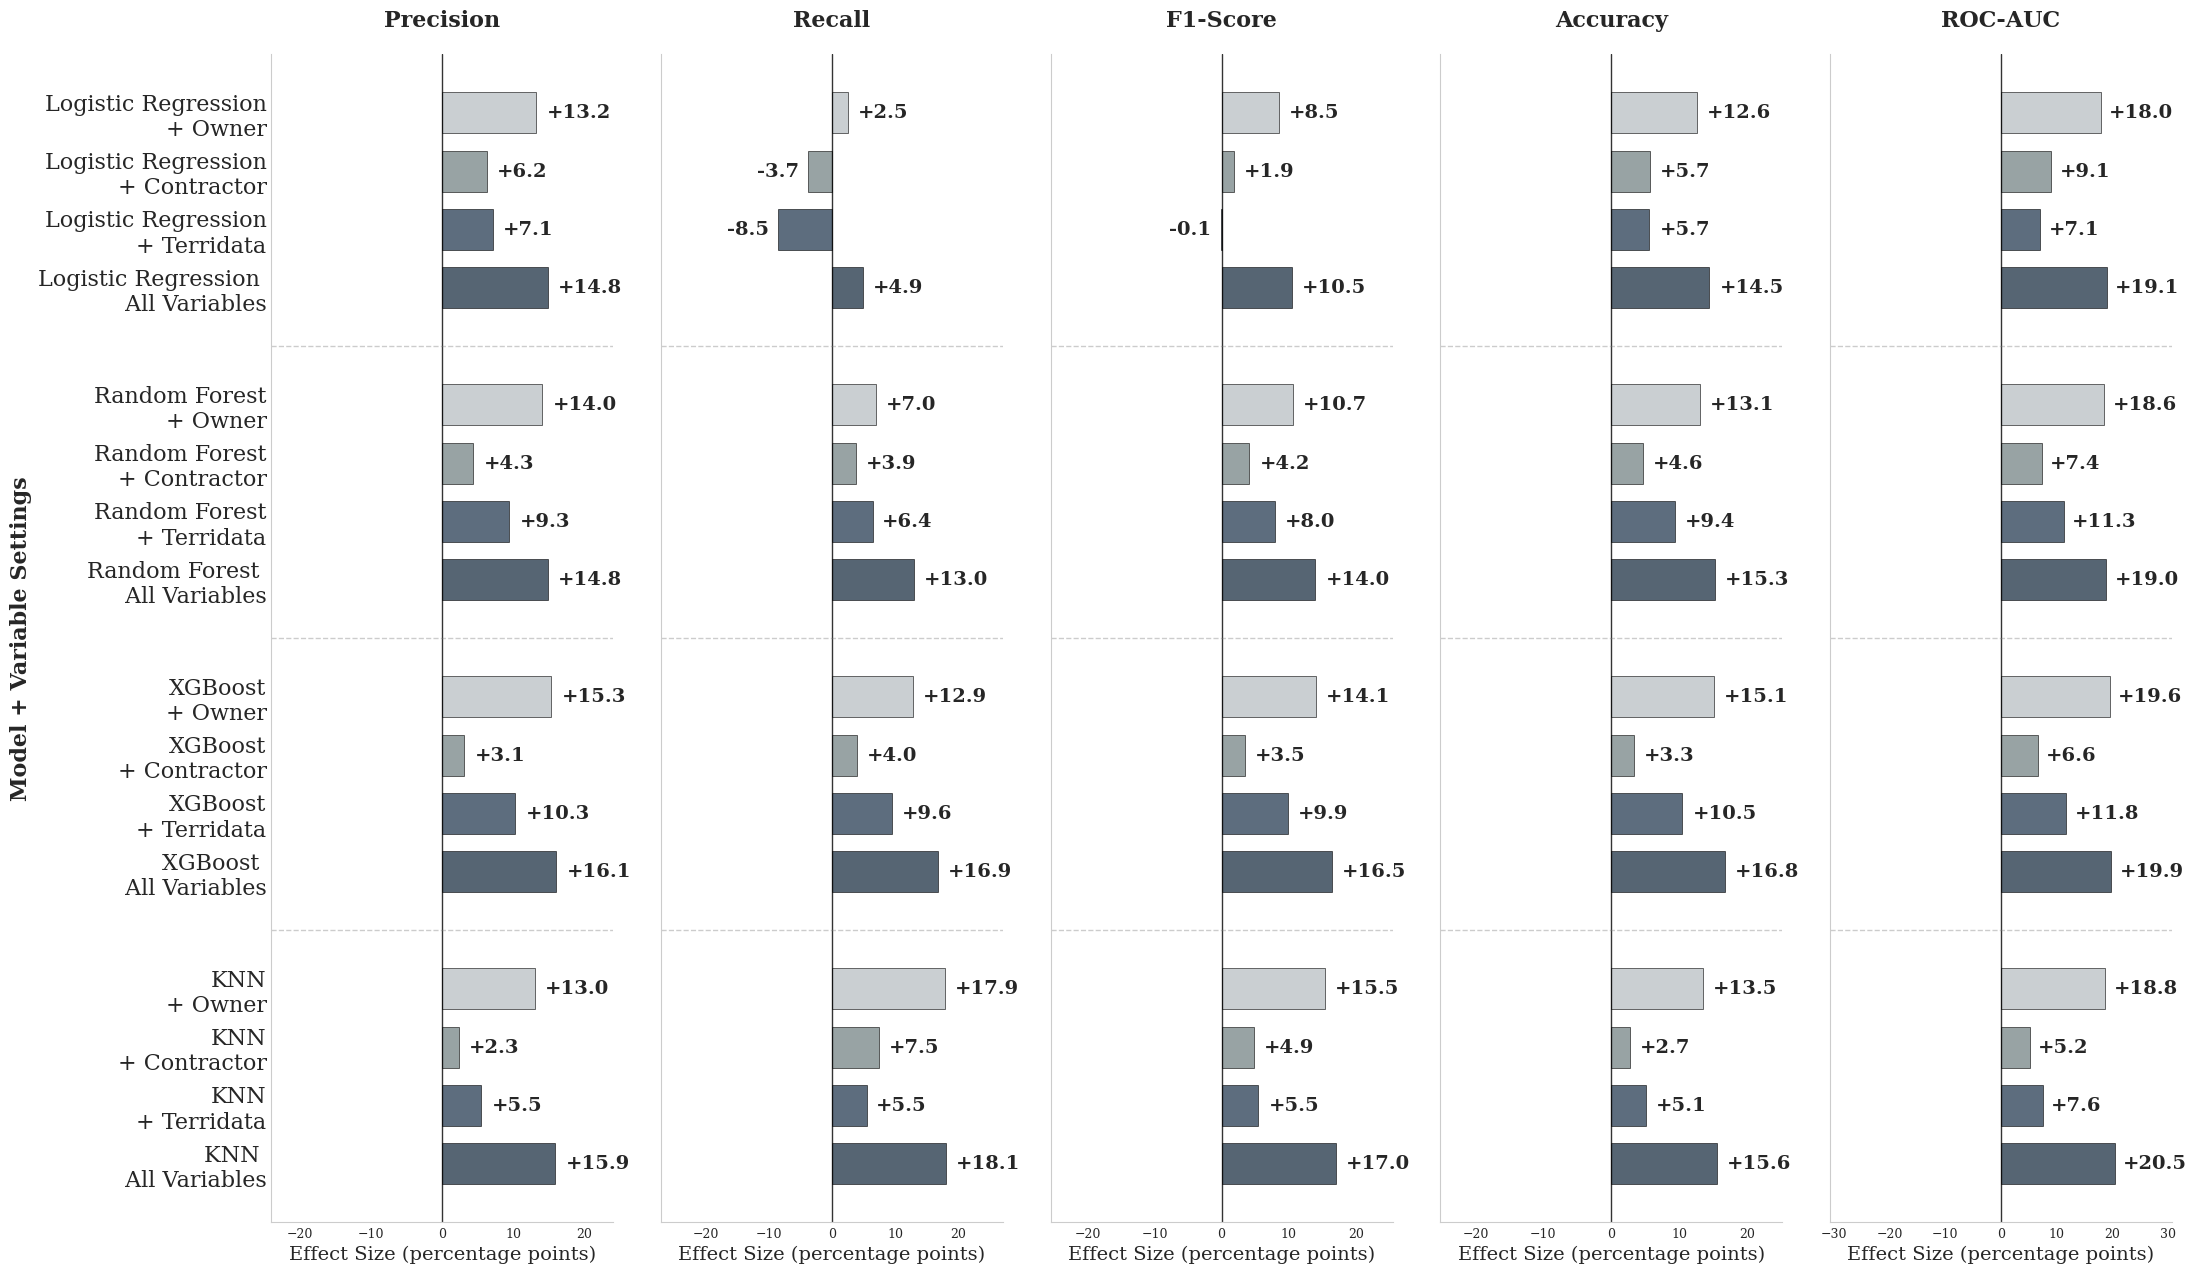

In [345]:
plot_efectos_variables(metrics_time_deviation)

In [346]:
metrics_time_deviation.set_index(['model','stage']).to_latex(
    index=True,
    float_format=lambda x: "{:.2f}".format(x)
)

'\\begin{tabular}{lllrrrrrl}\n\\toprule\n &  & setting & precision & recall & f1 & accuracy & roc_auc & model_setting \\\\\nmodel & stage &  &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{5}{*}{Logistic Regression} & S1 & Project & 53.33 & 65.77 & 58.90 & 54.92 & 56.33 & Logistic Regression - Project \\\\\n & S2 & Project + Owner & 66.52 & 68.31 & 67.40 & 67.55 & 74.30 & Logistic Regression - Project + Owner \\\\\n & S3 & Project + Contractor & 59.54 & 62.03 & 60.76 & 60.65 & 65.42 & Logistic Regression - Project + Contractor \\\\\n & S4 & Project + Terridata & 60.41 & 57.25 & 58.79 & 60.57 & 63.45 & Logistic Regression - Project + Terridata \\\\\n & S5 & All & 68.16 & 70.70 & 69.41 & 69.38 & 75.43 & Logistic Regression - All \\\\\n\\cline{1-9}\n\\multirow[t]{5}{*}{Random Forest} & S1 & Project & 54.48 & 60.84 & 57.49 & 55.80 & 58.89 & Random Forest - Project \\\\\n & S2 & Project + Owner & 68.48 & 67.86 & 68.17 & 68.87 & 77.51 & Random Forest - Project + Owner \\\\\n & S3 & Project 

### Análisis Inferencial

In [347]:
# Parametros
# results_time_dev = [lr_results_time_deviation, rf_results_time_deviation, xgb_results_time_deviation, knn_results_time_deviation]
# #results_cost_dev = [lr_results]
# modelos = {'Logistic Regression': LogisticRegression(max_iter=10000, solver='liblinear', random_state=42),
#            'Random Forest': RandomForestClassifier(random_state=42),
#            'XGBoost': XGBClassifier(random_state=42),
#            'KNN': KNeighborsClassifier()}
# results_cv_time_models = pd.DataFrame()
# stratified_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
# for res in results_time_dev:
#   for i,s in enumerate(res.keys()):
#     print(f"Setting:{s}")
#     print(f"Modelo: {res[s]['metrics']['model']}")
#     model_name = res[s]['metrics']['model']
#     model = modelos[model_name]
#     params = res[s]['best_params']

#     X = df[set_vars[i]].copy()
#     y = df['haveTimeDeviation(G5)'].copy()

#     numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
#     categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


#     # Crear transformadores para cada tipo de característica
#     numeric_transformer = Pipeline(steps=[
#         ('imputer', SimpleImputer(strategy='median')),
#         ('scaler', StandardScaler())
#     ])

#     categorical_transformer = Pipeline(steps=[
#         ('imputer', SimpleImputer(strategy='most_frequent')),
#         ('onehot', OneHotEncoder(handle_unknown='ignore'))
#     ])

#     # Preprocesamiento de características
#     preprocessor = ColumnTransformer(
#         transformers=[
#             ('num', numeric_transformer, numeric_features),
#             ('cat', categorical_transformer, categorical_features)
#         ]
#     )

#     resampler = SMOTEENN(sampling_strategy='auto', random_state=42)

#     base_pipeline = ImbPipeline([
#           ('preprocessor', preprocessor),
#           ('resampler', resampler),
#           ('classifier', model)
#       ])
#     # Configurar el modelo con los parámetros sugeridos
#     for param_name, param_value in params.items():
#       setattr(base_pipeline.named_steps['classifier'], param_name, param_value)
#     # Entrenar el modelo

#     scores = cross_validate(base_pipeline, X, y, cv=stratified_cv,
#                    scoring=['roc_auc','accuracy','f1','recall','precision'])

#     scores = pd.DataFrame(scores)
#     scores['model'] = model_name
#     scores['setting'] = s

#     results_cv_time_models = pd.concat([results_cv_time_models, scores], axis=0)
#     #base_pipeline.fit(X, y)
#     # Realizar predicciones
#     #y_pred = base_pipeline.predict(X)
#     # accuracy
#     #accuracy = accuracy_score(y, y_pred)
#     #print(f"Accuracy: {accuracy}")
# results_cv_time_models.to_csv('Data/doe_results_cv_time_models.csv', index=False)

In [348]:
# Multiplicar por 100 todas las métricas
results_cv_time_models = pd.read_csv('Data/doe_results_cv_time_models.csv')
metrics = ['test_roc_auc', 'test_accuracy', 'test_f1', 'test_recall', 'test_precision']
for i in metrics:
  results_cv_time_models[i] = np.round(results_cv_time_models[i]*100,2)
results_cv_time_models.groupby(['model','setting']).mean()

fit_time  score_time  test_roc_auc  \
model               setting                                       
KNN                 S1       0.093074    0.108670     56.740000   
                    S2       0.136391    0.303813     74.250000   
                    S3       0.622881    0.219849     61.583333   
                    S4       0.145501    0.162411     64.150000   
                    S5       1.265864    0.514186     74.760000   
Logistic Regression S1       0.134390    0.052429     57.853333   
                    S2       0.149200    0.042004     73.786667   
                    S3       0.721038    0.048973     65.783333   
                    S4       0.167193    0.060880     63.380000   
                    S5       1.253104    0.064513     74.380000   
Random Forest       S1       0.874425    0.179330     60.036667   
                    S2       2.148796    0.587222     76.550000   
                    S3       1.663560    0.198745     66.976667   
                    S4       0.952439    0.198005     69.930000   
                    S5       3.247142    0.335697     76.693333   
XGBoost             S1       0.195109    0.054675     58.703333   
                    S2       0.411112    0.056178     75.613333   
                    S3       0.780705    0.093788     64.736667   
                    S4       1.335100    0.062343     68.030000   
                    S5       1.319500    0.092803     76.540000   

                             test_accuracy    test_f1  test_recall  \
model               setting                                          
KNN                 S1           54.340000  51.750000    50.603333   
                    S2           67.980000  67.760000    68.506667   
                    S3           57.273333  57.113333    58.096667   
                    S4           60.336667  59.396667    59.130000   
                    S5           68.336667  69.460000    73.353333   
Logistic Regression S1           55.380000  55.333333    57.066667   
                    S2           67.540000  67.900000    69.940000   
                    S3           59.960000  62.540000    68.013333   
                    S4           59.566667  59.476667    60.430000   
                    S5           68.533333  69.996667    74.743333   
Random Forest       S1           56.303333  54.670000    55.046667   
                    S2           69.413333  69.720000    71.783333   
                    S3           61.303333  63.570000    68.820000   
                    S4           64.743333  64.583333    65.453333   
                    S5           70.296667  71.880000    77.303333   
XGBoost             S1           55.950000  54.213333    55.000000   
                    S2           69.303333  70.060000    73.220000   
                    S3           59.343333  62.000000    67.566667   
                    S4           62.870000  62.630000    63.346667   
                    S5           70.556667  72.033333    77.206667   

                             test_precision  
model               setting                  
KNN                 S1            53.820000  
                    S2            67.033333  
                    S3            56.286667  
                    S4            59.716667  
                    S5            66.003333  
Logistic Regression S1            54.360000  
                    S2            66.016667  
                    S3            57.893333  
                    S4            58.580000  
                    S5            65.823333  
Random Forest       S1            56.310000  
                    S2            67.850000  
                    S3            59.110000  
                    S4            63.743333  
                    S5            67.180000  
XGBoost             S1            56.003333  
                    S2            67.223333  
                    S3            57.316667  
                    S4            61.946667  
                    S5            67.516667

In [349]:
# Realizar ANOVA de dos factores y consolidar resultados
metrics = ['test_roc_auc', 'test_accuracy', 'test_f1', 'test_recall', 'test_precision']
anova_consolidated_time = pd.DataFrame()

lm_anova_time_dev = {}

#print("Realizando ANOVA para todas las métricas...")
#print("="*80)

for metric in metrics:
    #print(f"Procesando métrica: {metric}")

    # Realizar ANOVA
    model_anova = ols(f'{metric} ~ C(setting) + C(model)', data=results_cv_time_models).fit()
    lm_anova_time_dev[metric] = model_anova
    anova_results = anova_lm(model_anova, typ=2)

    # Extraer resultados (excluyendo la fila de residuos)
    temp = anova_results[['F', 'PR(>F)']].iloc[:-1].reset_index(names='Factor')
    temp['Metric'] = metric

    # Consolidar
    anova_consolidated_time = pd.concat([anova_consolidated_time, temp], axis=0, ignore_index=True)

    # Imprimir resultados individuales (opcional)
    #print(f"\nResultados ANOVA para {metric}:")
    #print(anova_results)
    #print("-" * 50)

# Reorganizar DataFrame para mejor presentación
anova_consolidated_time = anova_consolidated_time[['Metric', 'Factor', 'F', 'PR(>F)']]

model_names_anova = ['ROC AUC', 'Accuracy', 'F1', 'Recall', 'Precision']
# Consolidar modelos linales
lm_anova_consolidated_time = summary_col([lm_anova_time_dev['test_roc_auc'],
                                     lm_anova_time_dev['test_accuracy'],
                                     lm_anova_time_dev['test_f1'],
                                     lm_anova_time_dev['test_recall'],
                                     lm_anova_time_dev['test_precision']],
                                     model_names=model_names_anova,
                                    stars=True,  # Mostrar asteriscos de significancia
                                    float_format='%.3f',  # Formato de decimales
                                    info_dict={
                                        'N': lambda x: f"{int(x.nobs)}",
                                        'R2': lambda x: f"{x.rsquared:.3f}",
                                        'Adj. R2': lambda x: f"{x.rsquared_adj:.3f}",
                                        'F-stat': lambda x: f"{x.fvalue:.2f}",
                                        'Prob(F)': lambda x: f"{x.f_pvalue:.3f}"
                                    }
                                )

# Crear tabla pivotada para mejor visualización
print("\n" + "="*80)
print("TABLA CONSOLIDADA DE RESULTADOS ANOVA")
print("="*80)

# Opción 1: Tabla larga (una fila por métrica-factor)
anova_display_time = anova_consolidated_time.copy()
anova_display_time['F_formatted'] = anova_display_time['F'].apply(format_f_stat)
anova_display_time['p_formatted'] = anova_display_time['PR(>F)'].apply(format_pvalue)
anova_display_time['F_p_combined'] = anova_display_time['F_formatted'] + ' (' + anova_display_time['p_formatted'] + ')'

print("\nFormato tabla larga:")
print(anova_display_time[['Metric', 'Factor', 'F_formatted','p_formatted']].to_string(index=False))


TABLA CONSOLIDADA DE RESULTADOS ANOVA

Formato tabla larga:
        Metric     Factor F_formatted p_formatted
  test_roc_auc C(setting)      373.00  < 0.001***
  test_roc_auc   C(model)       24.71  < 0.001***
 test_accuracy C(setting)      264.47  < 0.001***
 test_accuracy   C(model)       14.91  < 0.001***
       test_f1 C(setting)       64.45  < 0.001***
       test_f1   C(model)        4.86     0.005**
   test_recall C(setting)       23.24  < 0.001***
   test_recall   C(model)        3.01      0.038*
test_precision C(setting)      155.69  < 0.001***
test_precision   C(model)        8.84  < 0.001***


In [350]:
print(lm_anova_consolidated_time)


                                 ROC AUC   Accuracy     F1      Recall  Precision
---------------------------------------------------------------------------------
Intercept                       56.606*** 54.180*** 51.783*** 50.636*** 54.209***
                                (0.479)   (0.464)   (1.062)   (2.139)   (0.538)  
C(setting)[T.S2]                16.717*** 13.066*** 14.868*** 16.433*** 11.907***
                                (0.535)   (0.519)   (1.187)   (2.391)   (0.601)  
C(setting)[T.S3]                6.437***  3.977***  7.314***  11.195*** 2.528*** 
                                (0.535)   (0.519)   (1.187)   (2.391)   (0.601)  
C(setting)[T.S4]                8.039***  6.386***  7.530***  7.661***  5.873*** 
                                (0.535)   (0.519)   (1.187)   (2.391)   (0.601)  
C(setting)[T.S5]                17.260*** 13.937*** 16.851*** 21.222*** 11.507***
                                (0.535)   (0.519)   (1.187)   (2.391)   (0.601)  
C(model)[T.Logi

In [351]:
anova_display_time['Metric'].replace({'test_roc_auc': 'ROC AUC', 'test_accuracy': 'Accuracy', 'test_f1': 'F1', 'test_recall': 'Recall', 'test_precision': 'Precision'}, inplace=True)
anova_display_time['Factor'].replace({'C(setting)': 'Setting', 'C(model)': 'Model'}, inplace=True)
anova_display_time.rename(columns={'F_formatted': 'Fo', 'p_formatted':'p'}, inplace=True)
anova_display_time[['Metric','Factor','Fo','p']].set_index(['Metric','Factor']).to_latex(
    index=True,
    float_format=lambda x: "{:.2f}".format(x)
)

'\\begin{tabular}{llll}\n\\toprule\n &  & Fo & p \\\\\nMetric & Factor &  &  \\\\\n\\midrule\n\\multirow[t]{2}{*}{ROC AUC} & Setting & 373.00 & < 0.001*** \\\\\n & Model & 24.71 & < 0.001*** \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{Accuracy} & Setting & 264.47 & < 0.001*** \\\\\n & Model & 14.91 & < 0.001*** \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{F1} & Setting & 64.45 & < 0.001*** \\\\\n & Model & 4.86 & 0.005** \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{Recall} & Setting & 23.24 & < 0.001*** \\\\\n & Model & 3.01 & 0.038* \\\\\n\\cline{1-4}\n\\multirow[t]{2}{*}{Precision} & Setting & 155.69 & < 0.001*** \\\\\n & Model & 8.84 & < 0.001*** \\\\\n\\cline{1-4}\n\\bottomrule\n\\end{tabular}\n'

In [352]:
lm_anova_consolidated_time.as_latex()

'\\begin{table}\n\\caption{}\n\\label{}\n\\begin{center}\n\\begin{tabular}{llllll}\n\\hline\n                                & ROC AUC   & Accuracy  & F1        & Recall    & Precision  \\\\\n\\hline\nIntercept                       & 56.606*** & 54.180*** & 51.783*** & 50.636*** & 54.209***  \\\\\n                                & (0.479)   & (0.464)   & (1.062)   & (2.139)   & (0.538)    \\\\\nC(setting)[T.S2]                & 16.717*** & 13.066*** & 14.868*** & 16.433*** & 11.907***  \\\\\n                                & (0.535)   & (0.519)   & (1.187)   & (2.391)   & (0.601)    \\\\\nC(setting)[T.S3]                & 6.437***  & 3.977***  & 7.314***  & 11.195*** & 2.528***   \\\\\n                                & (0.535)   & (0.519)   & (1.187)   & (2.391)   & (0.601)    \\\\\nC(setting)[T.S4]                & 8.039***  & 6.386***  & 7.530***  & 7.661***  & 5.873***   \\\\\n                                & (0.535)   & (0.519)   & (1.187)   & (2.391)   & (0.601)    \\\\\nC(setti

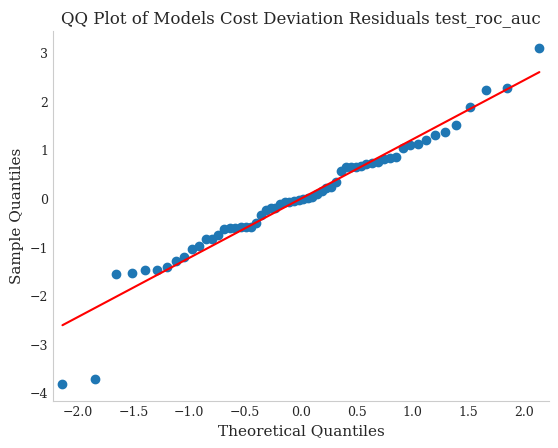

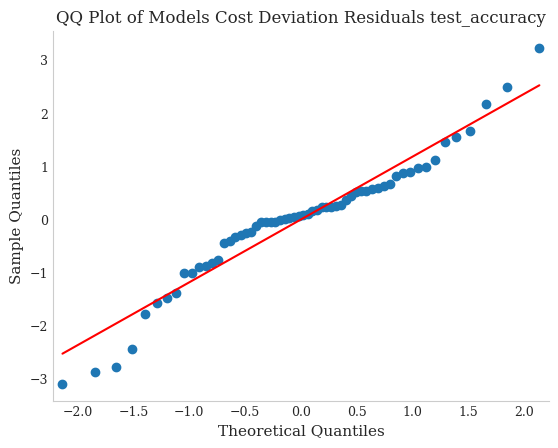

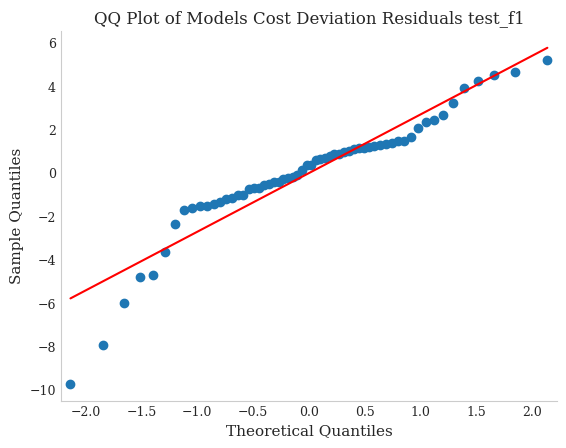

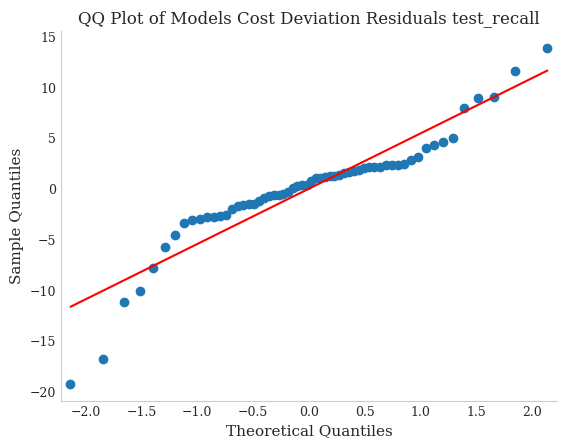

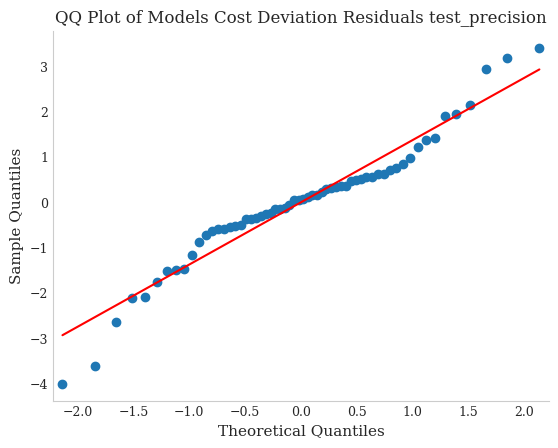

In [353]:
# QQ plot for all each model and metric
for metric in metrics:
  fig, ax = plt.subplots()
  sm.qqplot(lm_anova_time_dev[metric].resid, line='s', ax=ax)
  ax.set_title(f'QQ Plot of Models Cost Deviation Residuals {metric}')
  plt.show()

## Interpretación de Variables para desviaciones en costo

In [354]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

### Preparación de los datos

In [355]:
# Seleccionar X/y
X = df[vars_s5].copy()
y = df['haveCostDeviation(G5)'].copy()

# Seleccionar variables numéricas y categóricas
X_num = X.select_dtypes(include=['int64', 'float64'])
X_cat = X.select_dtypes(include=['object'])

# IMputación de datos
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')
X_num = pd.DataFrame(num_imputer.fit_transform(X_num), columns=X_num.columns)

# Estandarización de datos numéricos
X_scaler = StandardScaler().fit(X_num)
X_num_scaled = pd.DataFrame(X_scaler.transform(X_num), columns=X_num.columns)

# Transformación de variables categóricas
X_enc = OneHotEncoder(handle_unknown='ignore', drop='if_binary')
X_cat_enc = pd.DataFrame(X_enc.fit_transform(X_cat).toarray(), columns=X_enc.get_feature_names_out())

# Consolidar datos
X = pd.concat([X_num, X_cat_enc], axis=1)
X.head()

,contractMonthStart(G1),preelectoralYear(G1),projectIntensityMw(G1),contractMonthSigned(G1),electoralYear(G1),contractDurationDays(G1),bidContractRatio(G1),histAvgContractValue(G2),histPctDesvCost(G2),histPctDirectContracts(G2),histPctDesvTiempo(G2),histPctTenderContracts(G2),histAvgBidRatio(G2),histHHIValueProject(G2),penaltiesRecent(G2),totalCumContracts(G2),isBusinessGroup(G3),gdpByEconomicActivityConstruction(G4),gdpPerCapita(G4),openGovernmentTransparency(G4),managementComponent(G4),contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,databaseSource(G1)_SECOPII,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES
0,11.0,0.0,15.378019,9.0,0.0,180.0,0.999623,1223.930186,5.882353,0.0,0.0,70.588235,0.988179,4242.168026,0.0,17.0,1.0,213.80,28917372.0,88.78,56.01,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,6.0,0.0,31.086380,6.0,0.0,90.0,0.950032,3302.827068,7.142857,0.0,0.0,64.285714,0.988202,2630.129783,0.0,14.0,1.0,1250.23,28374996.0,88.89,55.10,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,1.0,13.161367,1.0,0.0,90.0,0.987883,2444.320445,60.000000,0.0,0.0,40.000000,0.96

### XGBoost

In [356]:
# Entregar el XGBoost
#xgb_model_cost = XGBClassifier(**xgb_results['S5']['best_params'], random_state=42)
#xgb_model_cost.fit(X, y)

# Estimar los SHAP values
#explainer_xgb_cost = shap.TreeExplainer(xgb_model_cost)
#shap_values_xgb_model = explainer_xgb_cost.shap_values(X)

# Exportar los explainers y los shap values for cost deviation models
#joblib.dump(explainer_xgb_cost, 'shap_xgb_cost_explainer.joblib')
#joblib.dump(shap_values_xgb_model, 'shap_xgb_cost_values.joblib')

# Cargar JavaScript
#shap.initjs()  # Esto debería cargar JavaScript

In [357]:
explainer_xgb_cost = joblib.load('shap_xgb_cost_explainer.joblib')
shap_values_xgb_model = joblib.load('shap_xgb_cost_values.joblib')

In [358]:
y_pred_xgb_cost = xgb_model_cost.predict(X)
# convert y_pred_xgb_cost to dataframe
y_pred_xgb_cost = pd.DataFrame(y_pred_xgb_cost, columns=['y_pred_xgb_cost'])
y_pred_xgb_cost[y_pred_xgb_cost['y_pred_xgb_cost'] == 1].head(20)

,y_pred_xgb_cost
2,1
6,1
8,1
14,1
20,1
25,1
26,1
27,1
31,1
42,1


In [359]:
# Gráfico de importancia de variables
shap.force_plot(explainer_xgb_cost.expected_value, shap_values_xgb_model[0, :], X.iloc[0, :])

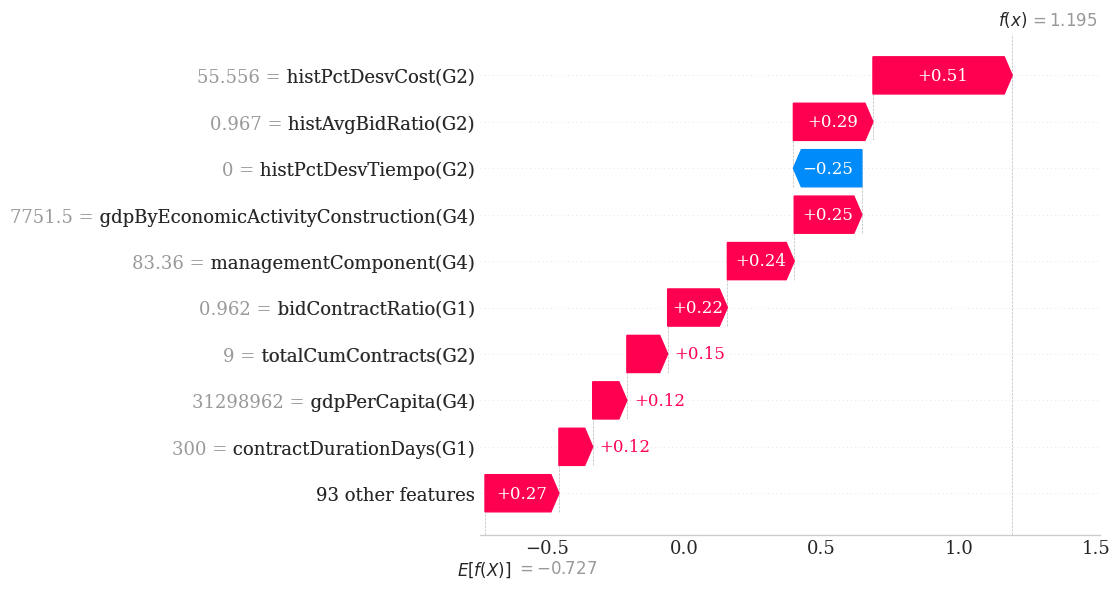

In [360]:
# Waterfall Plot
shap.plots.waterfall(shap.Explanation(values=shap_values_xgb_model[45],
                                     base_values=explainer_xgb_cost.expected_value,
                                     data=X.iloc[45]))

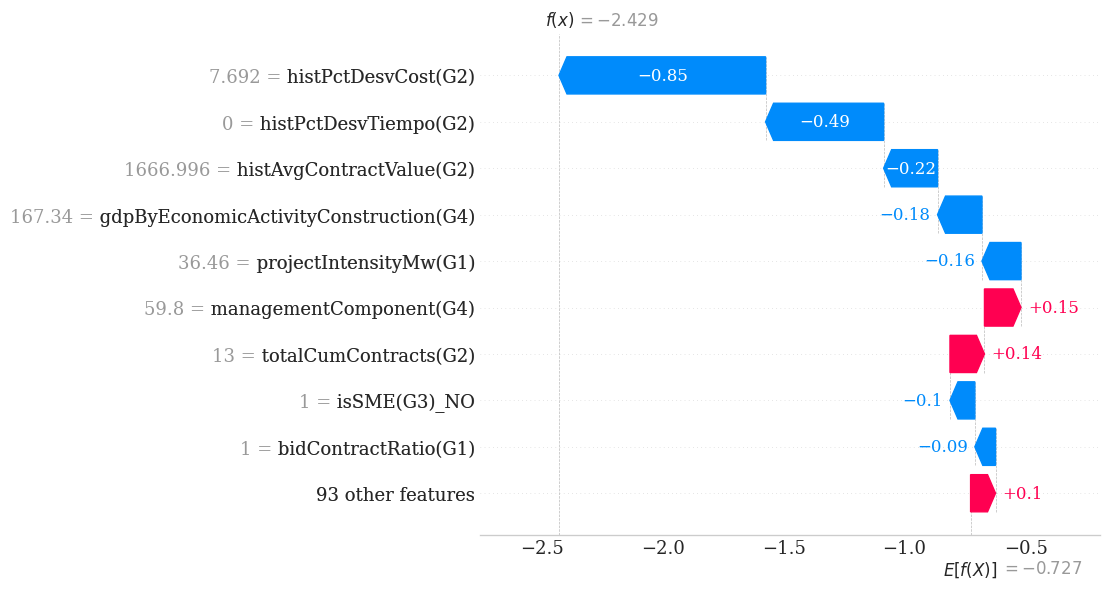

In [361]:
# Waterfall Plot
shap.plots.waterfall(shap.Explanation(values=shap_values_xgb_model[10],
                                     base_values=explainer_xgb_cost.expected_value,
                                     data=X.iloc[10]))

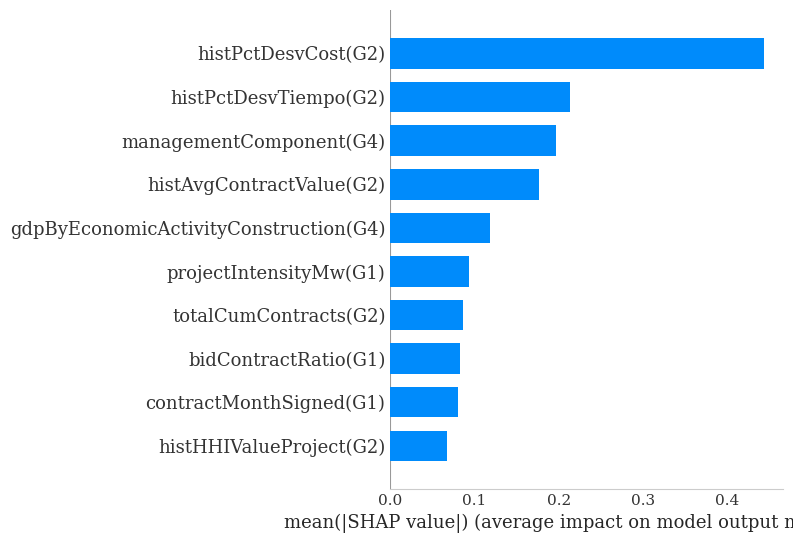

In [362]:
# Gráfico de importancia de variables
shap.summary_plot(shap_values_xgb_model, X, plot_type="bar", max_display=10)

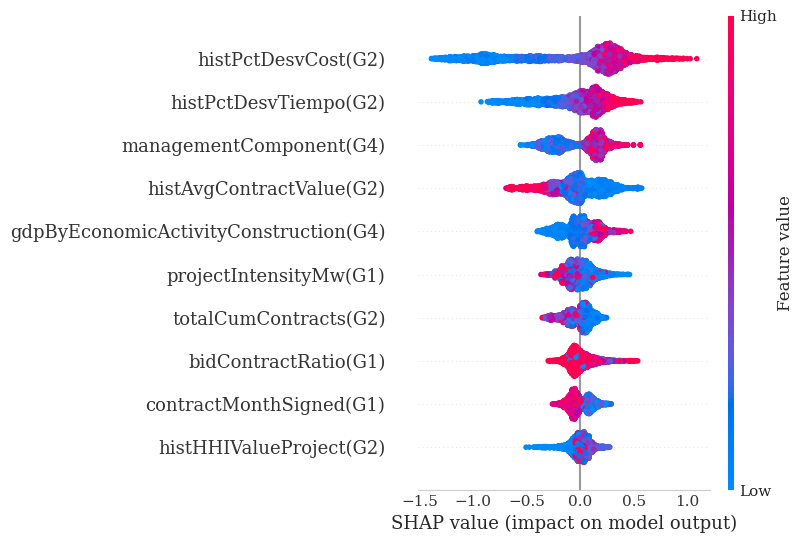

In [363]:
# Shap summary plot
shap.summary_plot(shap_values_xgb_model, X, max_display=10)

### Random Forest

In [364]:
# rf_best_param_cost = rf_results['S5']['best_params']
# if 'max_features_float' in rf_best_param_cost.keys():
#   rf_best_param_cost['max_features'] = rf_results['S5']['best_params']['max_features_float']
#   rf_best_param_cost.pop('max_features_float')
# if 'max_features_type' in rf_best_param_cost.keys():
#   rf_best_param_cost.pop('max_features_type')
# rf_best_param_cost

In [365]:
# rf_model_cost = RandomForestClassifier(random_state=42)
# rf_model_cost.set_params(**rf_best_param_cost)
# rf_model_cost.fit(X, y)

In [366]:
# Construir el explainer
# explainer_rf_cost = shap.TreeExplainer(rf_model_cost)
# Calcular los valores SHAP
# shap_values_rf_model = explainer_rf_cost.shap_values(X)
# joblib.dump(explainer_rf_cost, 'shap_rf_cost_explainer.joblib')
# joblib.dump(shap_values_rf_model, 'shap_rf_cost_values.joblib')

In [367]:
explainer_rf_cost = joblib.load('shap_rf_cost_explainer.joblib')
shap_values_rf_model = joblib.load('shap_rf_cost_values.joblib')

In [368]:
# rf_pred_cost = rf_model_cost.predict(X)
# rf_pred_cost

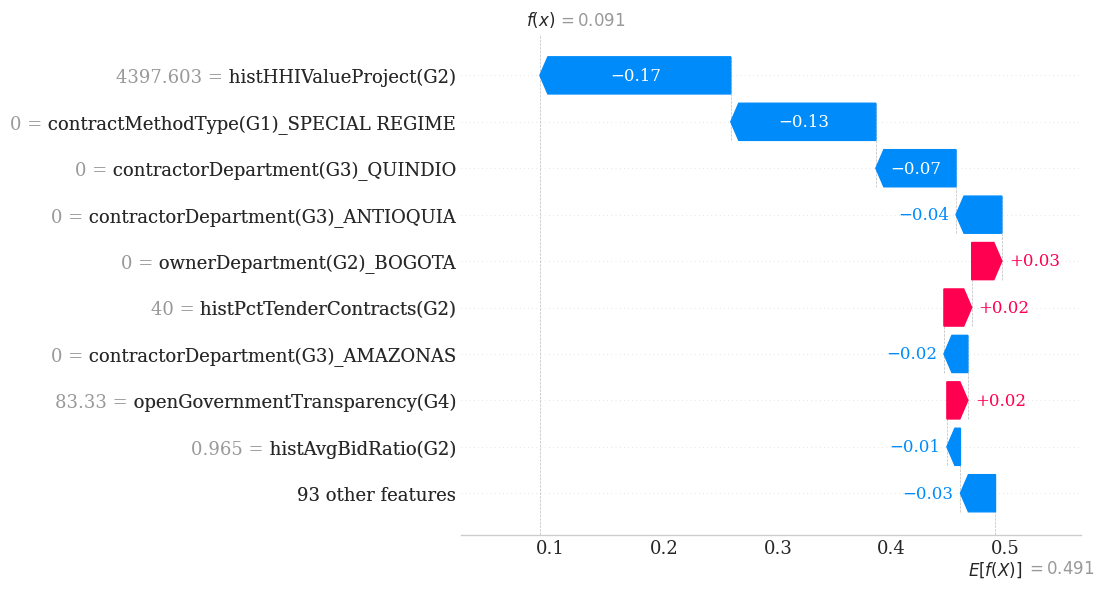

In [369]:
# Waterfall plot for instance 3
y_instance = 2
shap.plots.waterfall(shap.Explanation(shap_values_rf_model[y_instance, :, 1],
                                     base_values=explainer_rf_cost.expected_value[1],
                                     data=X.iloc[y_instance]))

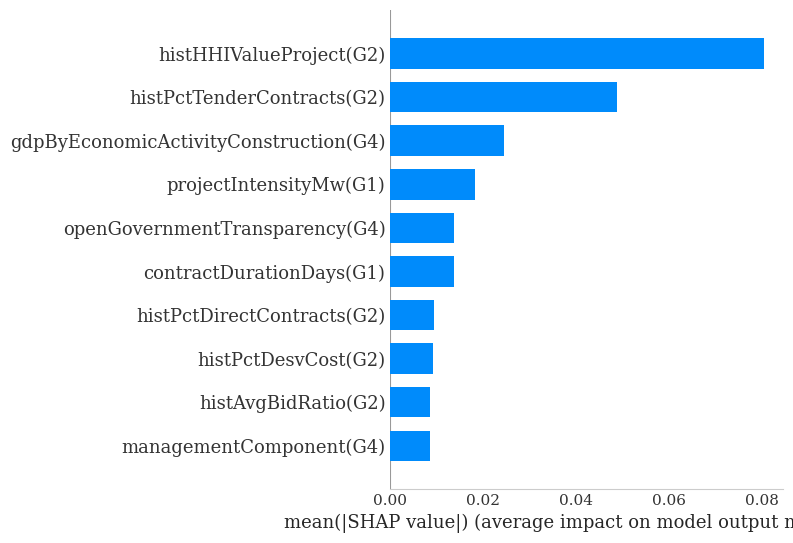

In [370]:
shap.summary_plot(shap_values_rf_model[:, :, 1], X, plot_type="bar", max_display=10)

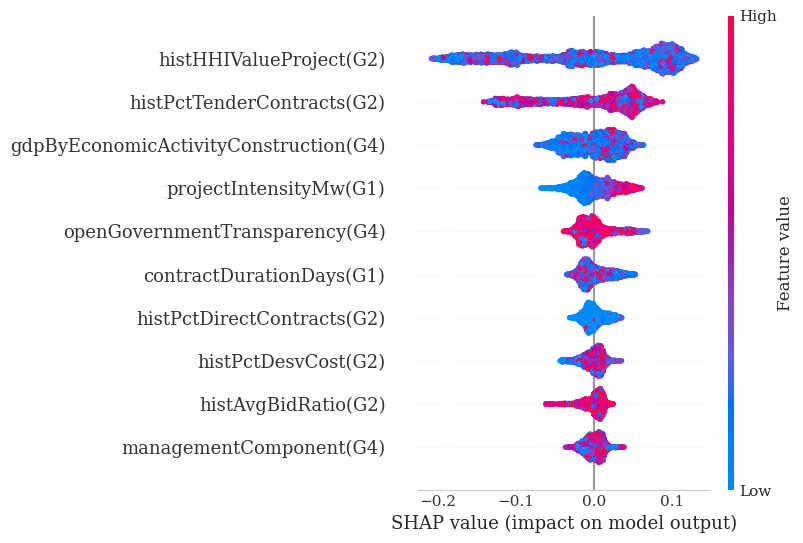

In [371]:
# Shap summary plot
shap.summary_plot(shap_values_rf_model[:, :, 1], X, max_display=10)

### Regresión Logística

In [372]:
# concatenar x_train_num_scaled y X_train_cat_enc
X_std = pd.concat([X_num_scaled, X_cat_enc], axis=1)
X_std

,contractMonthStart(G1),preelectoralYear(G1),projectIntensityMw(G1),contractMonthSigned(G1),electoralYear(G1),contractDurationDays(G1),bidContractRatio(G1),histAvgContractValue(G2),histPctDesvCost(G2),histPctDirectContracts(G2),histPctDesvTiempo(G2),histPctTenderContracts(G2),histAvgBidRatio(G2),histHHIValueProject(G2),penaltiesRecent(G2),totalCumContracts(G2),isBusinessGroup(G3),gdpByEconomicActivityConstruction(G4),gdpPerCapita(G4),openGovernmentTransparency(G4),managementComponent(G4),contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,databaseSource(G1)_SECOPII,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES
0,1.099962,-0.511132,-0.318160,0.465607,-0.554101,0.064760,0.232547,-0.431191,-1.035823,-0.213717,-1.511184,0.699276,-0.546311,0.217300,-0.405200,-0.518373,0.707574,-0.954483,0.864741,0.290459,-0.377592,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.347474,-0.511132,0.288705,-0.402599,-0.554101,-0.967685,-1.677355,0.165460,-0.973201,-0.213717,-1.511184,0.471470,-0.544306,-0.383706,-0.405200,-0.607987,0.707574,-0.603982,0.804995,0.296477,-0.454989,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.

In [373]:
# Entrenar regresión logistica con los mejores parametros
lr_model_cost = LogisticRegression()
#lr_model_cost.set_params(**lr_results['S4']['best_params'])
lr_model_cost.fit(X_std, y)

LogisticRegression()

In [374]:
# Explainer para la regresion logistica
explainer_lr_cost = shap.LinearExplainer(lr_model_cost, X_std)
# Calcular los valores SHAP
shap_values_lr_model = explainer_lr_cost.shap_values(X_std)

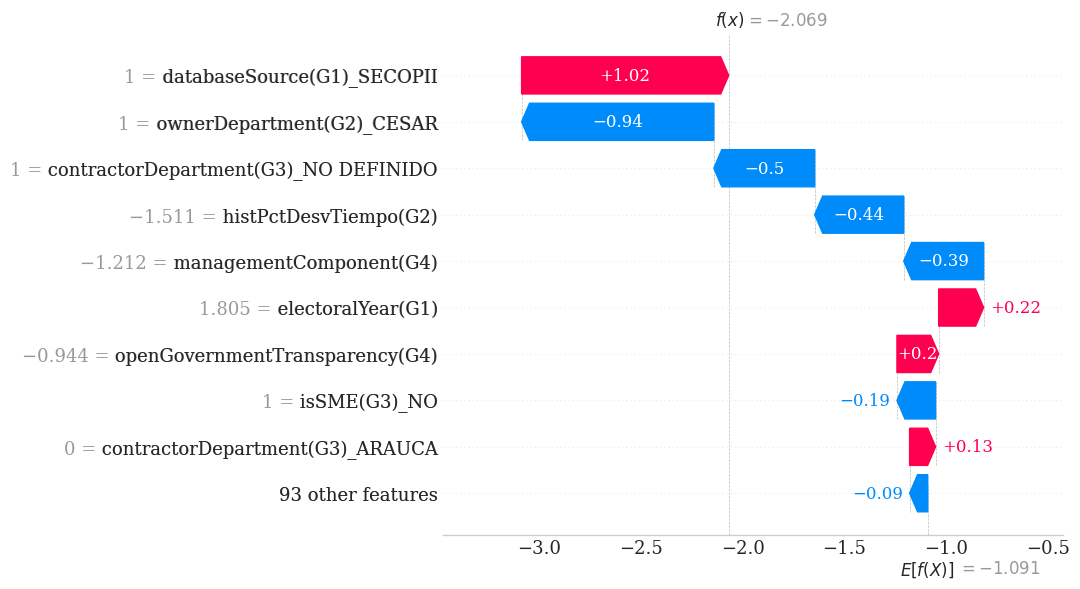

In [375]:
# waterfall plot
shap.plots.waterfall(shap.Explanation(values=shap_values_lr_model[3],
                                     base_values=explainer_lr_cost.expected_value,
                                     data=X_std.iloc[3]))

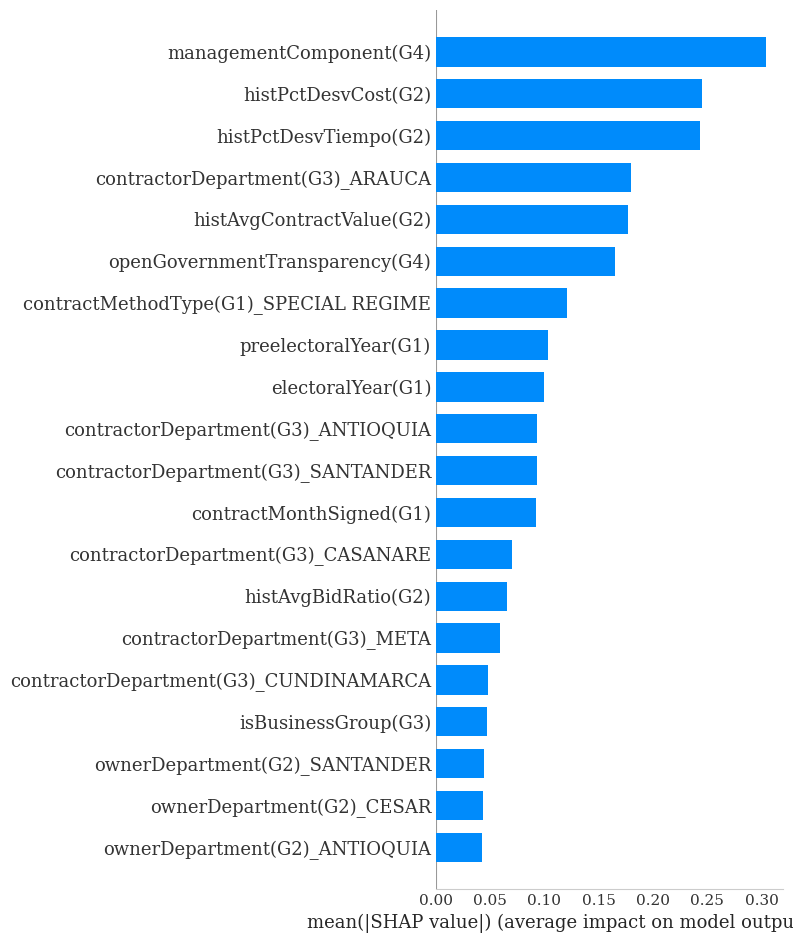

In [376]:
# Summary plot bar
shap.summary_plot(shap_values_lr_model, X_std, plot_type="bar")

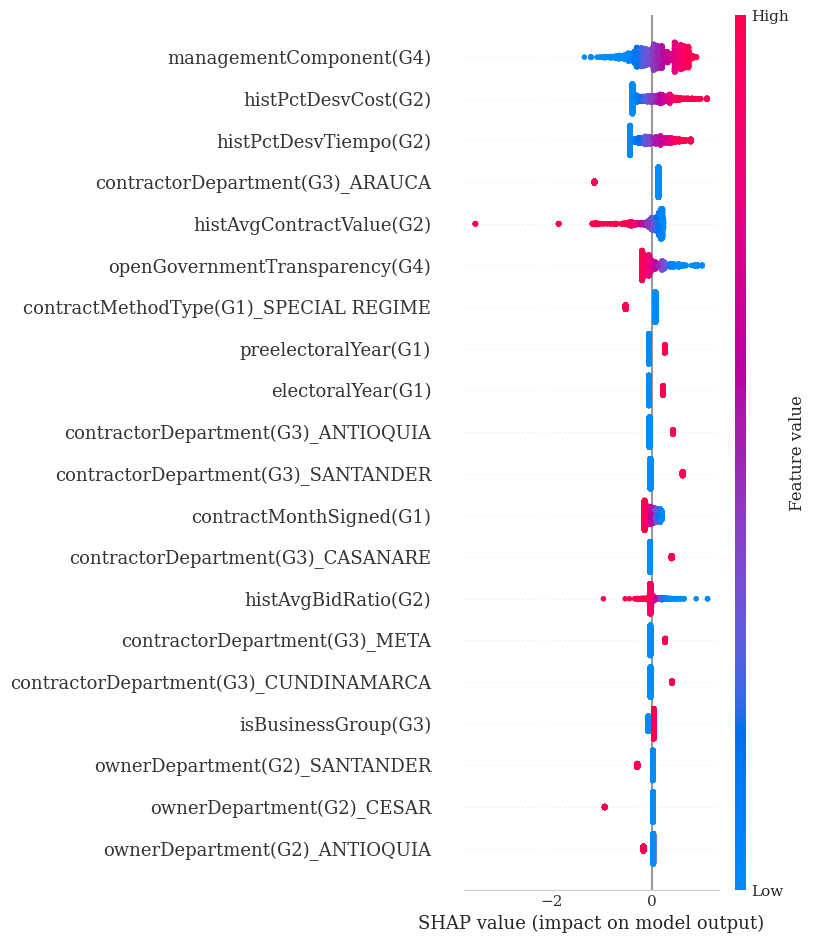

In [377]:
# Summary plot
shap.summary_plot(shap_values_lr_model, X_std)

### KNN

In [378]:
# Train KNN
# knn_model_cost = KNeighborsClassifier()
# knn_model_cost.set_params(**knn_results['S4']['best_params'])
# knn_model_cost.fit(X_std, y)

In [379]:
# Explainer para KNN
# explainer_knn_cost = shap.KernelExplainer(knn_model_cost.predict_proba, X_std)
# Calcular los valores SHAP
# shap_values_knn_model = explainer_knn_cost.shap_values(X_std)

## Análisis de Variables para desviaciones en tiempo

In [380]:
lr_results_time_deviation = joblib.load('Models V2/time_deviation_lr_results.joblib')
rf_results_time_deviation = joblib.load('Models V2/time_deviation_rf_results.joblib')
xgb_results_time_deviation = joblib.load('Models V2/time_deviation_xgb_results.joblib')
knn_results_time_deviation = joblib.load('Models V2/time_deviation_knn_results.joblib')

### Preparación de los datos

In [381]:
X = df[vars_s5].copy()
y = df['haveTimeDeviation(G5)'].copy()

In [382]:
# Convertir solo las columnas object en columnas categoricas
# for i in X.columns:
#  if X[i].dtype == 'object':
#    print(i)
#    X[i] = X[i].astype('category')

In [383]:
X_num = X.select_dtypes(include=['int64', 'float64'])
X_cat = X.select_dtypes(include=['object'])

In [384]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [385]:
X_num = pd.DataFrame(num_imputer.fit_transform(X_num), columns=X_num.columns)
X_num

,contractMonthStart(G1),preelectoralYear(G1),projectIntensityMw(G1),contractMonthSigned(G1),electoralYear(G1),contractDurationDays(G1),bidContractRatio(G1),histAvgContractValue(G2),histPctDesvCost(G2),histPctDirectContracts(G2),histPctDesvTiempo(G2),histPctTenderContracts(G2),histAvgBidRatio(G2),histHHIValueProject(G2),penaltiesRecent(G2),totalCumContracts(G2),isBusinessGroup(G3),gdpByEconomicActivityConstruction(G4),gdpPerCapita(G4),openGovernmentTransparency(G4),managementComponent(G4)
0,11.0,0.0,15.378019,9.0,0.0,180.0,0.999623,1223.930186,5.882353,0.0,0.000000,70.588235,0.988179,4242.168026,0.0,17.0,1.0,213.80,2.891737e+07,88.780000,56.010000
1,6.0,0.0,31.086380,6.0,0.0,90.0,0.950032,3302.827068,7.142857,0.0,0.000000,64.285714,0.988202,2630.129783,0.0,14.0,1.0,1250.23,2.837500e+07,88.890000,55.100000
2,1.0,1.0,13.161367,1.0,0.0,90.0,0.987883,2444.320445,60.000000,0.0,0.000000,40.000000,0.964652,4397.603109,1.0,5.0,1.0,7932.77,2.231207e+07,83.330000,80.510000
3,9.0,0.0,15.769037,8.0,1.0,225.0,0.952980,1689.653683,20.000000,0.0,0.000000,80.000000,0.993387,2989.022873,0.0,5.0,1.0,975.73,1.762169e+07,66.210000,46.200000
4,8.0,0.0,5.241605,6.0,1.0,194.0,0.954194,1689.653683,20.000000,0.0,0.000000,80.000000,0.993387,2989.022873,0.0,5.0,1.0,975.73,1.762169e+07,66.210000,46.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4533,7.0,0.0,23.279274,7.0,0.0,120.0,1.000000,3087.737726,75.000000,0.0,87.500000,100.000000,1.011304,2710.477776,0.0,8.0,0.0,7946.79,1.677290e+07,92.064286,67.931429
4534,5.0,0.0,12.396221,5.0,0.0,120.0,1.000000,326.951099,40.000000,0.0,20.000000,40.000000,0.999140,5540.804872,0.0,5.0,0.0,7946.79,1.677290e+07,71.684286,48.844286
4535,8.0,0.0,23.824000,8.0,0.0,270.0,0.998745,3415.167822,52.000000,0.0,68.000000,88.000000,0.996767,1549.125130,0.0,25.0,1.0,94.08,7.616826e+06,85.827143,50.991429
4536,8.0,0.0,12.530144,8.0,0.0,120.0,0.999073,1618.667610,11.111111,0.0,11.111111,88.888889,0.998596,1793.170753,0.0,9.0,1.0,2275.22,3.876559e+07,85.868571,58.284286


In [386]:
X_scaler = StandardScaler().fit(X_num)
X_num_scaled = pd.DataFrame(X_scaler.transform(X_num), columns=X_num.columns)
X_num_scaled

,contractMonthStart(G1),preelectoralYear(G1),projectIntensityMw(G1),contractMonthSigned(G1),electoralYear(G1),contractDurationDays(G1),bidContractRatio(G1),histAvgContractValue(G2),histPctDesvCost(G2),histPctDirectContracts(G2),histPctDesvTiempo(G2),histPctTenderContracts(G2),histAvgBidRatio(G2),histHHIValueProject(G2),penaltiesRecent(G2),totalCumContracts(G2),isBusinessGroup(G3),gdpByEconomicActivityConstruction(G4),gdpPerCapita(G4),openGovernmentTransparency(G4),managementComponent(G4)
0,1.099962,-0.511132,-0.318160,0.465607,-0.554101,0.064760,0.232547,-0.431191,-1.035823,-0.213717,-1.511184,0.699276,-0.546311,0.217300,-0.405200,-0.518373,0.707574,-0.954483,0.864741,0.290459,-0.377592
1,-0.347474,-0.511132,0.288705,-0.402599,-0.554101,-0.967685,-1.677355,0.165460,-0.973201,-0.213717,-1.511184,0.471470,-0.544306,-0.383706,-0.405200,-0.607987,0.707574,-0.603982,0.804995,0.296477,-0.454989
2,-1.794910,1.956441,-0.403796,-1.849610,-0.554101,-0.967685,-0.219617,-0.080935,1.652732,-0.213717,-1.511184,-0.406345,-2.618889,0.275249,2.467919,-0.876830,0.707574,1.655929,0.137124,-0.007733,1.706195
3,0.520988,-0.511132,-0.303053,0.176205,1.804726,0.580982,-1.563833,-0.297527,-0.334461,-0.213717,-1.511184,1.039468,-0.087576,-0.249902,-0.405200,-0.876830,0.707574,-0.696813,-0.379553,-0.944438,-1.211957
4,0.231500,-0.511132,-0.709762,-0.402599,1.804726,0.225362,-1.517053,-0.297527,-0.334461,-0.213717,-1.511184,1.039468,-0.087576,-0.249902,-0.405200,-0.876830,0.707574,-0.696813,-0.379553,-0.944438,-1.211957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4533,-0.057987,-0.511132,-0.012909,-0.113197,-0.554101,-0.623537,0.247065,0.103729,2.397929,-0.213717,2.094146,1.762374,1.490813,-0.353750,-0.405200,-0.787215,-1.413279,1.660670,-0.473053,0.470155,0.636356
4534,-0.636961,-0.511132,-0.433356,-0.692002,-0.554101,-0.623537,0.247054,-0.688628,0.659135,-0.213717,-0.687109,-0.406345,0.419251,0.701462,-0.405200,-0.876830,-1.413279,1.660670,-0.473053,-0.644918,-0.987054
4535,0.231500,-0.511132,0.008136,0.176205,-0.554101,1.097204,0.198728,0.197702,1.255293,-0.213717,1.290672,1.328630,0.210184,-0.786730,-0.405200,-0.279401,0.707574,-0.994970,-1.481655,0.128896,-0.804434
4536,0.231500,-0.511132,-0.428182,0.176205,-0.554101,-0.623537,0.211353,-0.317900,-0.776059,-0.213717,-1.053365,1.360759,0.371339,-0.695744,-0.405200,-0.757344,0.707574,-0.257349,1.949588,0.131162,-0.184158


In [387]:
X_enc = OneHotEncoder(handle_unknown='ignore', drop='if_binary')
X_cat_enc = pd.DataFrame(X_enc.fit_transform(X_cat).toarray(), columns=X_enc.get_feature_names_out())
X_cat_enc

,contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,databaseSource(G1)_SECOPII,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [388]:
# concatenar x_train_num_scaled y X_train_cat_enc
X = pd.concat([X_num, X_cat_enc], axis=1)
X

,contractMonthStart(G1),preelectoralYear(G1),projectIntensityMw(G1),contractMonthSigned(G1),electoralYear(G1),contractDurationDays(G1),bidContractRatio(G1),histAvgContractValue(G2),histPctDesvCost(G2),histPctDirectContracts(G2),histPctDesvTiempo(G2),histPctTenderContracts(G2),histAvgBidRatio(G2),histHHIValueProject(G2),penaltiesRecent(G2),totalCumContracts(G2),isBusinessGroup(G3),gdpByEconomicActivityConstruction(G4),gdpPerCapita(G4),openGovernmentTransparency(G4),managementComponent(G4),contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,databaseSource(G1)_SECOPII,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES
0,11.0,0.0,15.378019,9.0,0.0,180.0,0.999623,1223.930186,5.882353,0.0,0.000000,70.588235,0.988179,4242.168026,0.0,17.0,1.0,213.80,2.891737e+07,88.780000,56.010000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,6.0,0.0,31.086380,6.0,0.0,90.0,0.950032,3302.827068,7.142857,0.0,0.000000,64.285714,0.988202,2630.129783,0.0,14.0,1.0,1250.23,2.837500e+07,88.890000,55.100000,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,1.0,13.161367,1.0,0.0,90.0,0.987883,2444.320445,60

### XGBoost

In [389]:
# # xgb_results_time_deviation['S5']['best_params']
# # xgb_model_time = XGBClassifier(**xgb_results_time_deviation['S5']['best_params'], random_state=42)
# # xgb_model_time.fit(X, y)

# explainer_xgb_time = shap.TreeExplainer(xgb_model_time)
# shap_values_xgb_model_time = explainer_xgb_time.shap_values(X)

# # Exportar los explainers y los shap values for cost deviation models
# joblib.dump(explainer_xgb_time, 'shap_xgb_time_explainer.joblib')
# joblib.dump(shap_values_xgb_model_time, 'shap_xgb_time_values.joblib')

In [390]:
explainer_xgb_time = joblib.load('shap_xgb_time_explainer.joblib')
shap_values_xgb_model_time = joblib.load('shap_xgb_time_values.joblib')

In [391]:
# Gráfico de importancia de variables
# shap.force_plot(explainer_xgb_time.expected_value, shap_values_xgb_model_time[0, :], X.iloc[0, :])

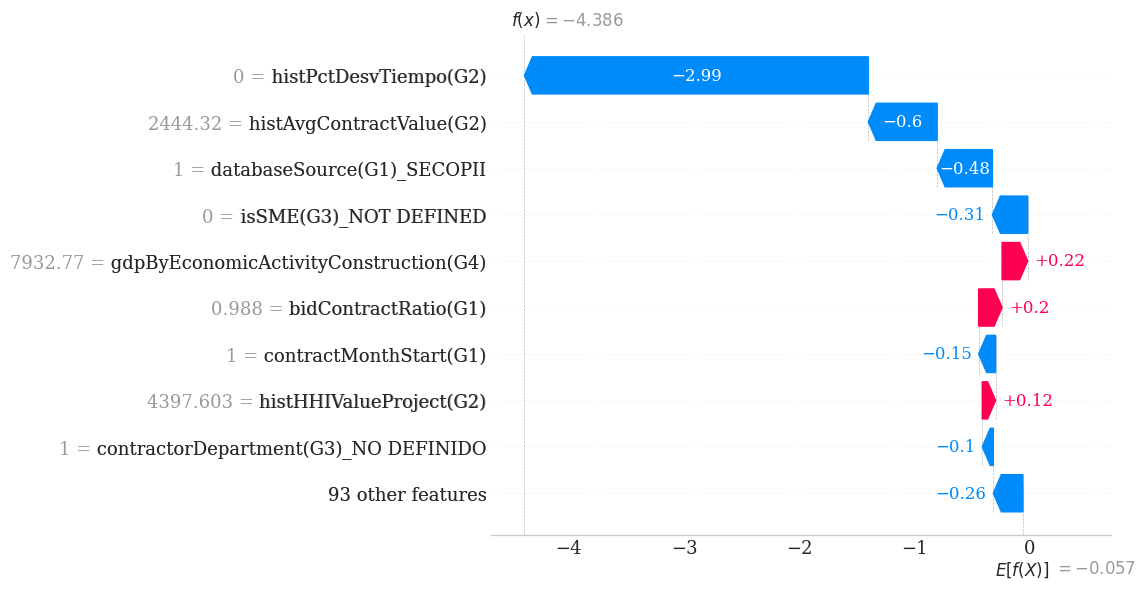

In [392]:
shap.plots.waterfall(shap.Explanation(values=shap_values_xgb_model_time[2],
                                     base_values=explainer_xgb_time.expected_value,
                                     data=X.iloc[2]))

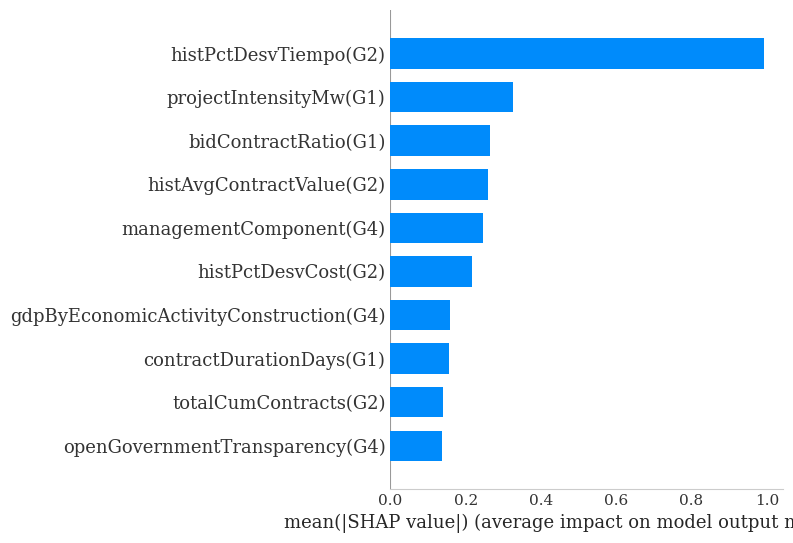

In [393]:
shap.summary_plot(shap_values_xgb_model_time, X, plot_type="bar", max_display=10)

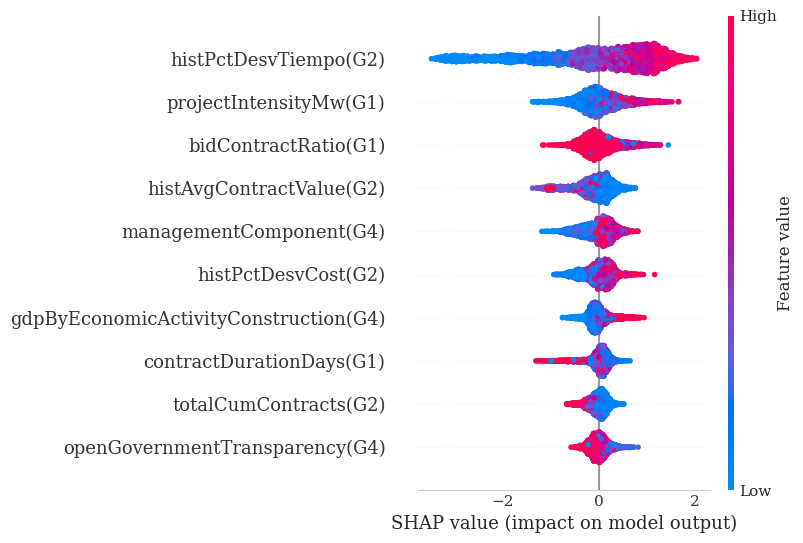

In [394]:
# Shap summary plot
shap.summary_plot(shap_values_xgb_model_time, X, max_display=10)

### Random Forest

In [395]:
# rf_best_param_time = rf_results_time_deviation['S5']['best_params']
# if 'max_features_float' in rf_best_param_cost.keys():
#   rf_best_param_time['max_features'] = rf_results_time_deviation['S5']['best_params']['max_features_float']
#   rf_best_param_time.pop('max_features_float')
# if 'max_features_type' in rf_best_param_time.keys():
#   rf_best_param_time.pop('max_features_type')
# rf_best_param_time

In [396]:
# rf_model_time = RandomForestClassifier(random_state=42)
# rf_model_time.set_params(**rf_best_param_time)
# rf_model_time.fit(X, y)

In [397]:
# Construir el explainer
# explainer_rf_time = shap.TreeExplainer(rf_model_time)
# Calcular los valores SHAP
# shap_values_rf_model_time = explainer_rf_time.shap_values(X)

# Save results
# joblib.dump(explainer_rf_time, 'shap_rf_time_explainer.joblib')
# joblib.dump(shap_values_rf_model_time, 'shap_rf_time_values.joblib')

<Axes: >

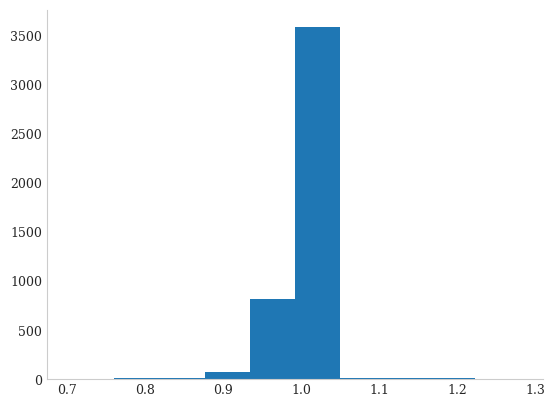

In [398]:
df['bidContractRatio(G1)'].hist()

In [399]:
explainer_rf_time = joblib.load('shap_rf_time_explainer.joblib')
shap_values_rf_model_time = joblib.load('shap_rf_time_values.joblib')

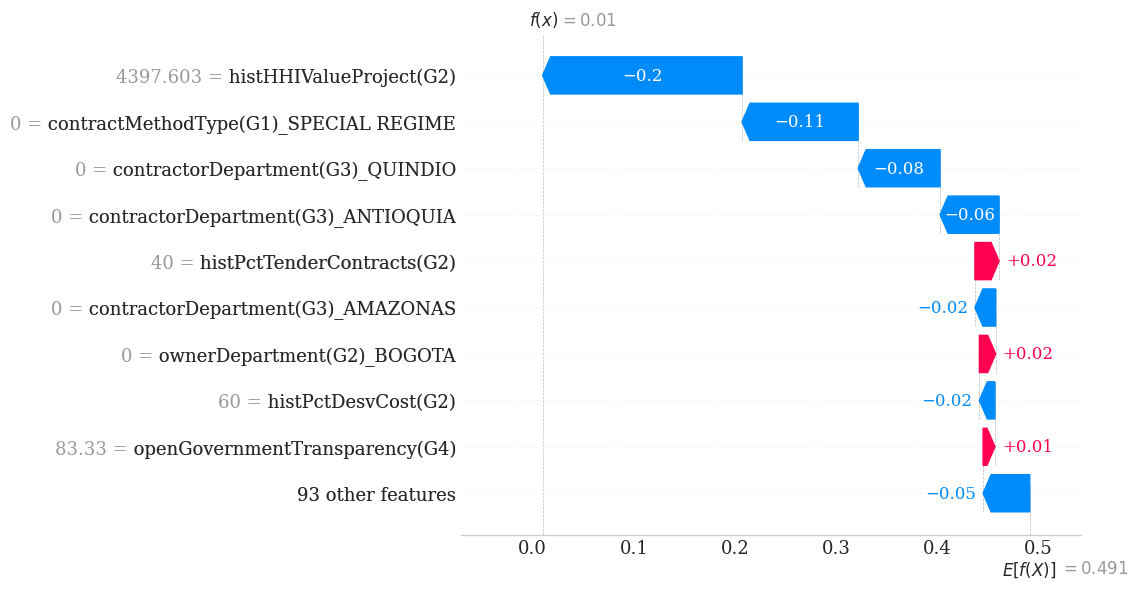

In [400]:
# Waterfall plot for instance 3
y_instance = 2
shap.plots.waterfall(shap.Explanation(shap_values_rf_model_time[y_instance, :, 1],
                                     base_values=explainer_rf_time.expected_value[1],
                                     data=X.iloc[y_instance]))

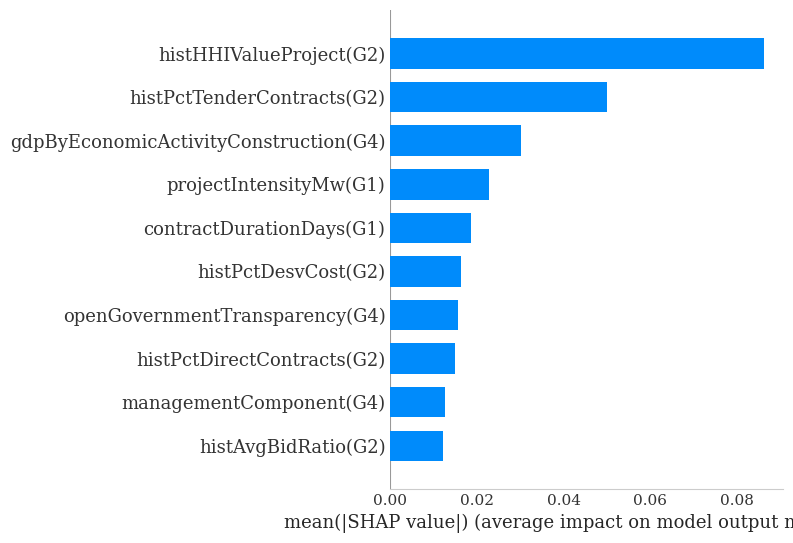

In [401]:
shap.summary_plot(shap_values_rf_model_time[:, :, 1], X, plot_type="bar", max_display=10)

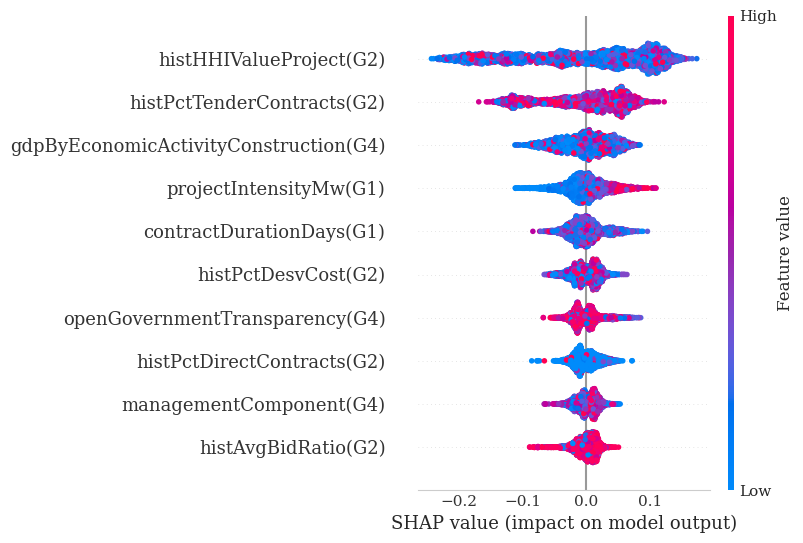

In [402]:
# Shap summary plot
shap.summary_plot(shap_values_rf_model_time[:, :, 1], X, max_display=10)

### Regresión Logística

In [403]:
# concatenar x_train_num_scaled y X_train_cat_enc
X_std = pd.concat([X_num_scaled, X_cat_enc], axis=1)
X_std

,contractMonthStart(G1),preelectoralYear(G1),projectIntensityMw(G1),contractMonthSigned(G1),electoralYear(G1),contractDurationDays(G1),bidContractRatio(G1),histAvgContractValue(G2),histPctDesvCost(G2),histPctDirectContracts(G2),histPctDesvTiempo(G2),histPctTenderContracts(G2),histAvgBidRatio(G2),histHHIValueProject(G2),penaltiesRecent(G2),totalCumContracts(G2),isBusinessGroup(G3),gdpByEconomicActivityConstruction(G4),gdpPerCapita(G4),openGovernmentTransparency(G4),managementComponent(G4),contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,databaseSource(G1)_SECOPII,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES
0,1.099962,-0.511132,-0.318160,0.465607,-0.554101,0.064760,0.232547,-0.431191,-1.035823,-0.213717,-1.511184,0.699276,-0.546311,0.217300,-0.405200,-0.518373,0.707574,-0.954483,0.864741,0.290459,-0.377592,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.347474,-0.511132,0.288705,-0.402599,-0.554101,-0.967685,-1.677355,0.165460,-0.973201,-0.213717,-1.511184,0.471470,-0.544306,-0.383706,-0.405200,-0.607987,0.707574,-0.603982,0.804995,0.296477,-0.454989,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.

In [404]:
# Entrenar regresión logistica con los mejores parametros
lr_model_time = LogisticRegression()
#lr_model_cost.set_params(**lr_results['S4']['best_params'])
lr_model_time.fit(X_std, y)

LogisticRegression()

In [405]:
# Explainer para la regresion logistica
explainer_lr_time = shap.LinearExplainer(lr_model_time, X_std)
# Calcular los valores SHAP
shap_values_lr_model_time = explainer_lr_time.shap_values(X_std)

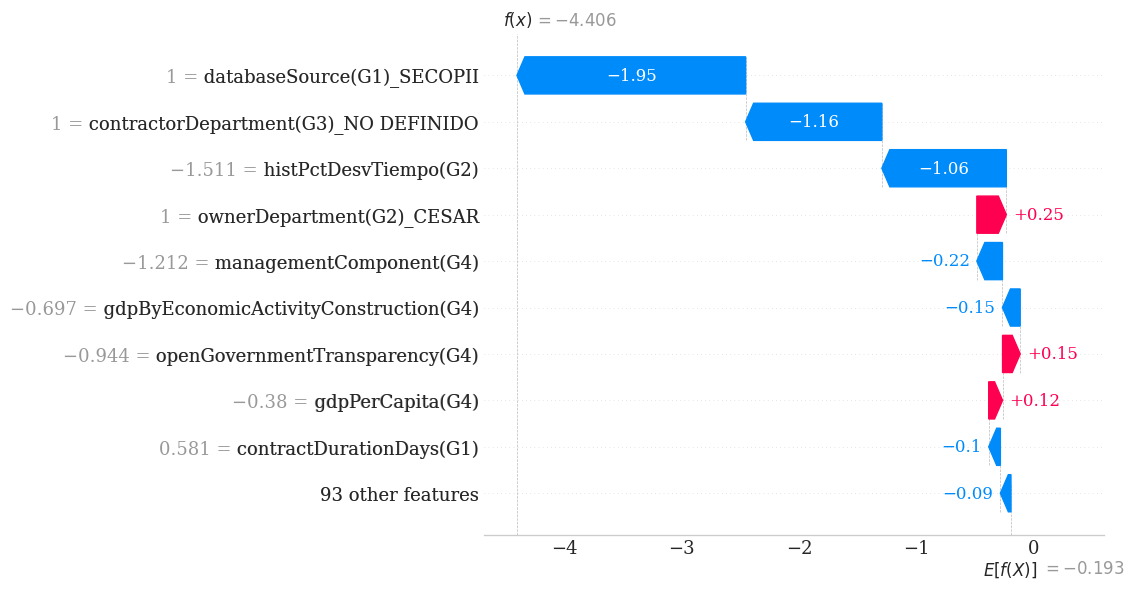

In [406]:
# waterfall plot
shap.plots.waterfall(shap.Explanation(values=shap_values_lr_model_time[3],
                                     base_values=explainer_lr_time.expected_value,
                                     data=X_std.iloc[3]))

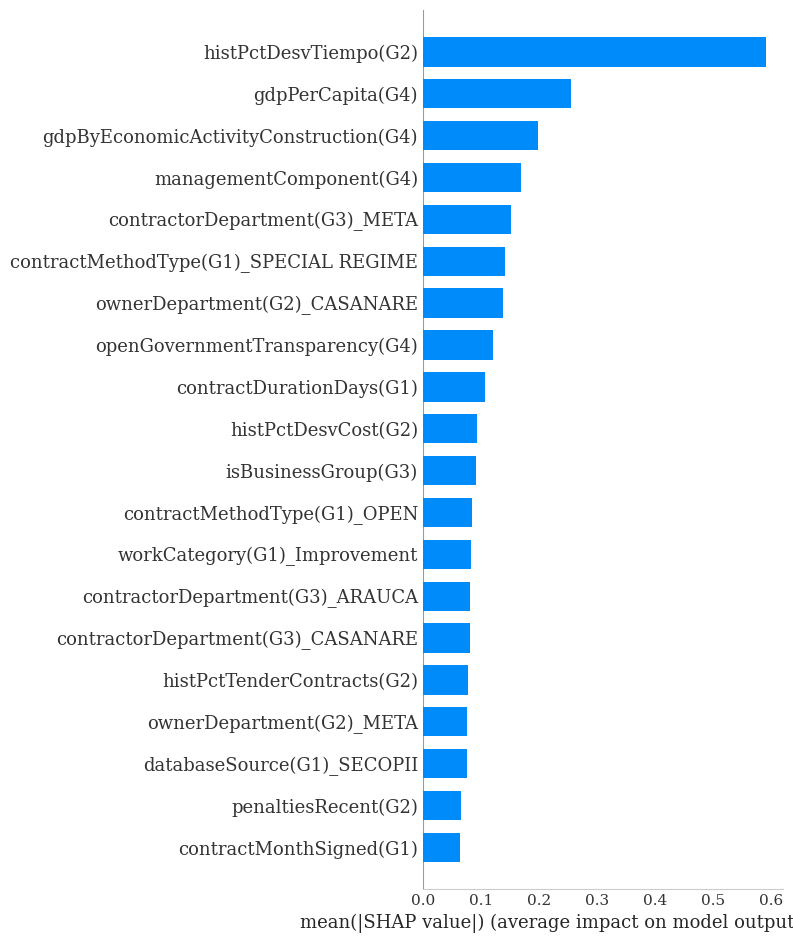

In [407]:
# Summary plot bar
shap.summary_plot(shap_values_lr_model_time, X_std, plot_type="bar")

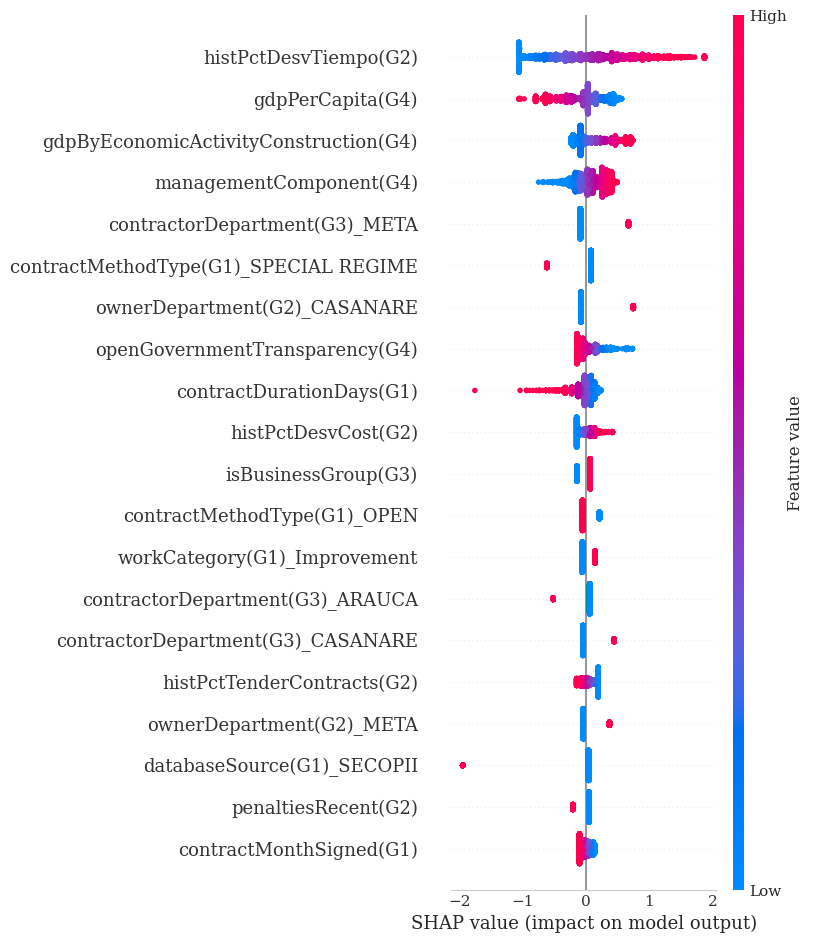

In [408]:
# Summary plot
shap.summary_plot(shap_values_lr_model_time, X_std)